# Forecasting Extrínseco de Series Temporales en Procesos de Moldeo por Inyección
## Cuaderno 1: Análisis Exploratorio y Preprocesamiento de Datos

**Autor:** Juan Miguel Martínez Muñoz  
**Institución:** Facultad de Ingeniería de la Universidad Nacional de Asunción (FIUNA)  
**Programa:** Maestría en Ciencias de la Inteligencia Artificial  

---

## 1. Descripción del Problema Industrial
En la industria manufacturera de plásticos, el proceso de moldeo por inyección es altamente dinámico, no lineal y extremadamente sensible a variaciones termodinámicas. Las anomalías durante el ciclo pueden generar defectos irreversibles en las piezas y comprometer la integridad de las matrices. Actualmente, la validación de estas métricas ocurre tras finalizar el ciclo o mediante simulaciones computacionales lentas.

Este proyecto aborda el problema como una **Regresión Extrínseca de Series Temporales (Sequence-to-Scalar)**. El objetivo es anticipar la calidad final del ciclo proyectando únicamente la dinámica termomecánica de los primeros **3 segundos** de inyección hacia 8 variables estáticas críticas simultáneas (enfoque *Multi-Output*), permitiendo una alerta temprana eficiente en el entorno industrial (Edge AI).

## 2. Dataset Utilizado
Los datos provienen del **"Injection Molding Dataset"** publicado por el German Plastics Center (SKZ) (https://b2share.eudat.eu/records/fkk68-zyf30).
* **Descripción:** Registros de experimentos de moldeo por inyección utilizando material ABS, superando el mínimo de 100 observaciones requeridas para el modelado temporal.
* **Archivos principales:**
  * `viscometer_pressure_data.parquet`: Contiene las trayectorias temporales de alta resolución (presión frontal y trasera dependiente del tiempo).
  * `quality_table_data.parquet`: Contiene los parámetros escalares medidos por los sensores al finalizar el ciclo completo (aprox. 30 segundos).
* **Variables del Modelado:**
  * *Features Temporales (X):* Matriz secuencial de presión frontal y trasera durante la fase activa del polímero.
  * *Targets Escalares (Y):* 8 parámetros numéricos críticos, destacando la Presión Máxima de Masa (`MEAS_KM_Max MasDr [bar]`), contrapresiones y tiempos totales.

## 3. Metodología de Preprocesamiento (Pipeline)
El flujo de trabajo en este cuaderno está diseñado para preparar tensores limpios y estructurados para los modelos de Machine Learning y Deep Learning, garantizando la reproducibilidad:

1. **Ingesta y Unificación:** Fusión de archivos `.parquet` enlazando las series temporales con sus resultados finales mediante los identificadores únicos `META_experiment` y `META_run`.
2. **Análisis Exploratorio (EDA):** Identificación de multicolinealidad, depuración de variables redundantes y mapeo de correlaciones entre las variables del molde.
3. **Truncamiento Temporal Estratégico:** Recorte de todas las series temporales estrictamente a los primeros 3 segundos, aislando el pico de presión de inyección y descartando la fase de enfriamiento.
4. **Ingeniería de Características (Para ML Clásico):** Extracción de descriptores estadísticos estáticos (media, desviación estándar, integral) a partir del segmento truncado de 3 segundos.
5. **Escalado de Datos:** Aplicación de `StandardScaler` en la notebook 02_modelos.ipnyb.

---

# Sección 1: Importación de librerías base

In [1]:
# importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#configuracion visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente")

Librerías importadas correctamente


# Sección 2: Descarga de datos mediante código

In [2]:
import os

# Creamos la carpeta 'data' en el entorno de Colab para mantener la estructura de tu proyecto
os.makedirs('data', exist_ok=True)

print("Iniciando descargas desde el repositorio oficial B2SHARE...")

# Descarga de la tabla de calidad (Target) usando su PID oficial
print("Descargando quality_table_data.parquet (22.2 kB)...")
!wget -q -O data/quality_table_data.parquet "http://hdl.handle.net/11304/c8e7e28e-12e4-4faa-a8bd-436072a6870c"

# Descarga de los datos del viscosímetro (Features) usando su PID oficial
print("Descargando viscometer_pressure_data.parquet (181.5 MB)... Esto puede tardar un momento.")
!wget -q -O data/viscometer_pressure_data.parquet "http://hdl.handle.net/11304/8d20219d-4997-44a1-8aa1-b0348e2e4261"

# Definimos las rutas donde quedaron guardados los archivos
path_quality = 'data/quality_table_data.parquet'
path_pressure = 'data/viscometer_pressure_data.parquet'

print("\n¡Descargas completadas exitosamente!")
print(f"Ruta de calidad: {path_quality}")
print(f"Ruta de presión: {path_pressure}")

Iniciando descargas desde el repositorio oficial B2SHARE...
Descargando quality_table_data.parquet (22.2 kB)...
Descargando viscometer_pressure_data.parquet (181.5 MB)... Esto puede tardar un momento.

¡Descargas completadas exitosamente!
Ruta de calidad: data/quality_table_data.parquet
Ruta de presión: data/viscometer_pressure_data.parquet


# Sección 3: EDA, Carga de Datos en Pandas
A partir de aquí, creamos los dataframes y empezamos con la exploración de los datos.

In [3]:
# Cargar los datasets a la memoria usando pandas
print("Cargando tabla de calidad (variables objetivo)...")
df_quality = pd.read_parquet(path_quality)

print("Cargando datos de presión (esto tomará unos segundos)...")
df_pressure = pd.read_parquet(path_pressure)

print("\n--- DIMENSIONES DE LOS DATOS ---")
print(f"Dataset de Presión (Series Temporales): {df_pressure.shape[0]} filas y {df_pressure.shape[1]} columnas")
print(f"Dataset de Calidad (Targets): {df_quality.shape[0]} filas y {df_quality.shape[1]} columnas")

Cargando tabla de calidad (variables objetivo)...
Cargando datos de presión (esto tomará unos segundos)...

--- DIMENSIONES DE LOS DATOS ---
Dataset de Presión (Series Temporales): 18000000 filas y 6 columnas
Dataset de Calidad (Targets): 68 filas y 25 columnas


In [4]:
df_quality.head()

,META_experiment,META_run,META_CycleStart,META_CycleEnd,MEAS_KM_Zyklus- Zeit Z [s],MEAS_KM_Plast- Zeit Z [s],MEAS_KM_Spritz- Zeit Z [s],MEAS_KM_Umsch MasDrZ [bar],MEAS_KM_Max MasDr [bar],MEAS_KM_Masse- Polster [cm³],...,MEAS_KM_Max F Leistung [kW],MEAS_KM_Fläche Leistung [Wh],MEAS_KM_Fläche Spritzweg [mm*s],MEAS_KM_Max F Spritzge [mm/s],MEAS_KM_Fläche Spritzge [mm/s*s],MEAS_KM_Max StauDr [bar],MEAS_KM_Energie ZylHtg [Wh],MEAS_KM_Energie HptAntr [Wh],MEAS_KM_Energie PeriAuto [Wh],MEAS_KM_Energie Gesamt [Wh]
0,1,1,688,692,41.92,12.57,2.00,1018,1153,9.51,...,5.733,2.6,286.9,52.0,103.7,571.0,11.2,24.0,6.2,41.4
1,1,2,688,692,41.92,12.55,2.00,1018,1153,9.51,...,5.737,2.6,286.9,52.0,103.7,572.0,13.5,24.1,6.3,43.9
2,1,3,688,692,41.92,12.58,2.00,1017,1152,9.52,...,5.719,2.5,286.9,52.0,103.7,572.0,11.7,24.0,6.3,42.0
3,1,4,688,692,41.91,12.54,2.00,1017,1152,9.51,...,5.728,2.5,286.7,52.0,103.7,572.0,12.5,24.0,6.3,42.8
4,2,1,703,707,41.26,12.55,1.37,954,1273,9.49,...,9.548,2.8,246.0,78.0,103.9,571.0,10.8,24.1,6.1,41.0


In [5]:
# en df_quality podemos ver los diferentes experimentos realizados y los posibles targets

In [6]:
df_quality.columns.tolist()

['META_experiment',
 'META_run',
 'META_CycleStart',
 'META_CycleEnd',
 'MEAS_KM_Zyklus- Zeit Z [s]',
 'MEAS_KM_Plast- Zeit Z [s]',
 'MEAS_KM_Spritz- Zeit Z [s]',
 'MEAS_KM_Umsch MasDrZ [bar]',
 'MEAS_KM_Max MasDr [bar]',
 'MEAS_KM_Masse- Polster [cm³]',
 'MEAS_KM_Max WkzDr1 [bar]',
 'MEAS_KM_Max F WkzDr1 [bar]',
 'MEAS_KM_Fläche WkzDr1 [bar*s]',
 'MEAS_KM_Max F Massedr [bar]',
 'MEAS_KM_Fläche Massedr [bar*s]',
 'MEAS_KM_Max F Leistung [kW]',
 'MEAS_KM_Fläche Leistung [Wh]',
 'MEAS_KM_Fläche Spritzweg [mm*s]',
 'MEAS_KM_Max F Spritzge [mm/s]',
 'MEAS_KM_Fläche Spritzge [mm/s*s]',
 'MEAS_KM_Max StauDr [bar]',
 'MEAS_KM_Energie ZylHtg [Wh]',
 'MEAS_KM_Energie HptAntr [Wh]',
 'MEAS_KM_Energie PeriAuto [Wh]',
 'MEAS_KM_Energie Gesamt [Wh]']

In [7]:
# mientras que en df_pressure vemos tambien los experimentos y lo que miden los sensores con cada combinacion de parametros en la maquina

In [8]:
df_pressure.head()

,META_experiment,META_run,Time[s],MEAS_pressure_frontsensor_bar,MEAS_pressure_backsensor_bar,MEAS_pressure_difference_bar
0,1,1,0.0000,1.292234,-0.532786,1.825020
1,1,1,0.0001,1.528618,-0.297733,1.826351
2,1,1,0.0002,1.607413,-0.532786,2.140199
3,1,1,0.0003,1.607413,-0.532786,2.140199
4,1,1,0.0004,1.292234,-0.376084,1.668318


In [9]:
df_pressure.columns.tolist()

['META_experiment',
 'META_run',
 'Time[s]',
 'MEAS_pressure_frontsensor_bar',
 'MEAS_pressure_backsensor_bar',
 'MEAS_pressure_difference_bar']

In [10]:
#aplicamos estadistica basica...

In [11]:
for i in range(2,6,1):
  print (df_pressure[[df_pressure.columns[i]]].describe())

            Time[s]
count  1.800000e+07
mean   7.693626e+01
std    4.697521e+01
min    0.000000e+00
25%    3.798650e+01
50%    7.661810e+01
75%    1.158948e+02
max    1.558066e+02
       MEAS_pressure_frontsensor_bar
count                   1.800000e+07
mean                    3.289304e+02
std                     2.605485e+02
min                    -9.140192e-01
25%                     5.298159e+01
50%                     5.381997e+02
75%                     5.522252e+02
max                     1.113559e+03
       MEAS_pressure_backsensor_bar
count                  1.800000e+07
mean                   2.445546e+02
std                    2.037574e+02
min                   -1.316295e+00
25%                    2.657662e+01
50%                    3.500090e+02
75%                    4.532755e+02
max                    5.070242e+02
       MEAS_pressure_difference_bar
count                  1.800000e+07
mean                   8.437584e+01
std                    8.416878e+01
min                

### Relación entre los Conjuntos de Datos: Causa y Efecto

Al observar las tablas generadas, es fundamental establecer la naturaleza física y operativa de cada una para comprender la arquitectura de este proyecto. La interacción entre estos conjuntos representa la relación de variables de control, respuesta dinámica y métricas de calidad en un proceso industrial:

* **`df_pressure` / `viscometer_pressure_data` (Telemetría de Alta Resolución):** Constituye una serie temporal dinámica. Muestra de forma dependiente del tiempo cómo reacciona físicamente el polímero (presión frontal y trasera del viscosímetro) al ser inyectado.
* **`df_quality` / `quality_table_data` (Resultados de Calidad):** Funciona como una tabla de resumen escalar que registra los parámetros medidos por los sensores internos de la máquina inyectora para cada ciclo. Incluye métricas definitivas evaluadas tras el proceso, como la presión máxima de la cavidad o el consumo de energía (bajo el prefijo `MEAS_KM_`).

> **El Rol del Modelo Sustituto:**
> El objetivo de integrar estos datos es enlazar la causa con el efecto. Los modelos predictivos aprenderán a extraer patrones de la telemetría inicial en `df_pressure` (los primeros 3 segundos de la curva transitoria) para inferir las condiciones del proceso y **predecir** las métricas finales detalladas en `df_quality`. Esto permite anticipar el comportamiento y la calidad de la pieza sin necesidad de esperar a que finalice el ciclo físico ni depender de costosas simulaciones computacionales.

# Sección 4: EDA, Target y Entradas
Se exploran diferentes opciones de targets y se van observando la naturaleza de los datos obtenidos con los sensores.


In [12]:
import math

In [13]:
# 1. Filtramos las columnas de metadatos que no son objetivos físicos
cols_excluidas = ['META_experiment', 'META_run', 'META_CycleStart', 'META_CycleEnd'] #columnas con datos irrelevantes
candidatos = [col for col in df_quality.columns if col not in cols_excluidas]#columnas con datos a evaluar, posibles targets

In [14]:
len(df_quality.columns)

25

In [15]:
len(candidatos)

21

In [16]:
# 2. Separamos los targets útiles de los que tienen varianza zero
targets_validos = []
targets_descartados = []

for col in candidatos:
    if df_quality[col].std() == 0:
        targets_descartados.append(col)
    else:
        targets_validos.append(col)

print(f" Variables descartadas (Varianza Cero - Sensores inactivos): {len(targets_descartados)}")
for td in targets_descartados:
    print(f"   - {td}")

print(f"\n Variables válidas (Con varianza - Posibles Targets): {len(targets_validos)}")

 Variables descartadas (Varianza Cero - Sensores inactivos): 3
   - MEAS_KM_Max WkzDr1 [bar]
   - MEAS_KM_Max F WkzDr1 [bar]
   - MEAS_KM_Fläche WkzDr1 [bar*s]

 Variables válidas (Con varianza - Posibles Targets): 18


In [17]:
# reducir los targets de 25 a 18, lo que nos ayuda a centrarnos en los mas relevantes.

### Visualización de los datos
Se exploran los 18 targets a fin de entender su comportamiento y ver cuales podrían de ser interés para nuestro estudio.

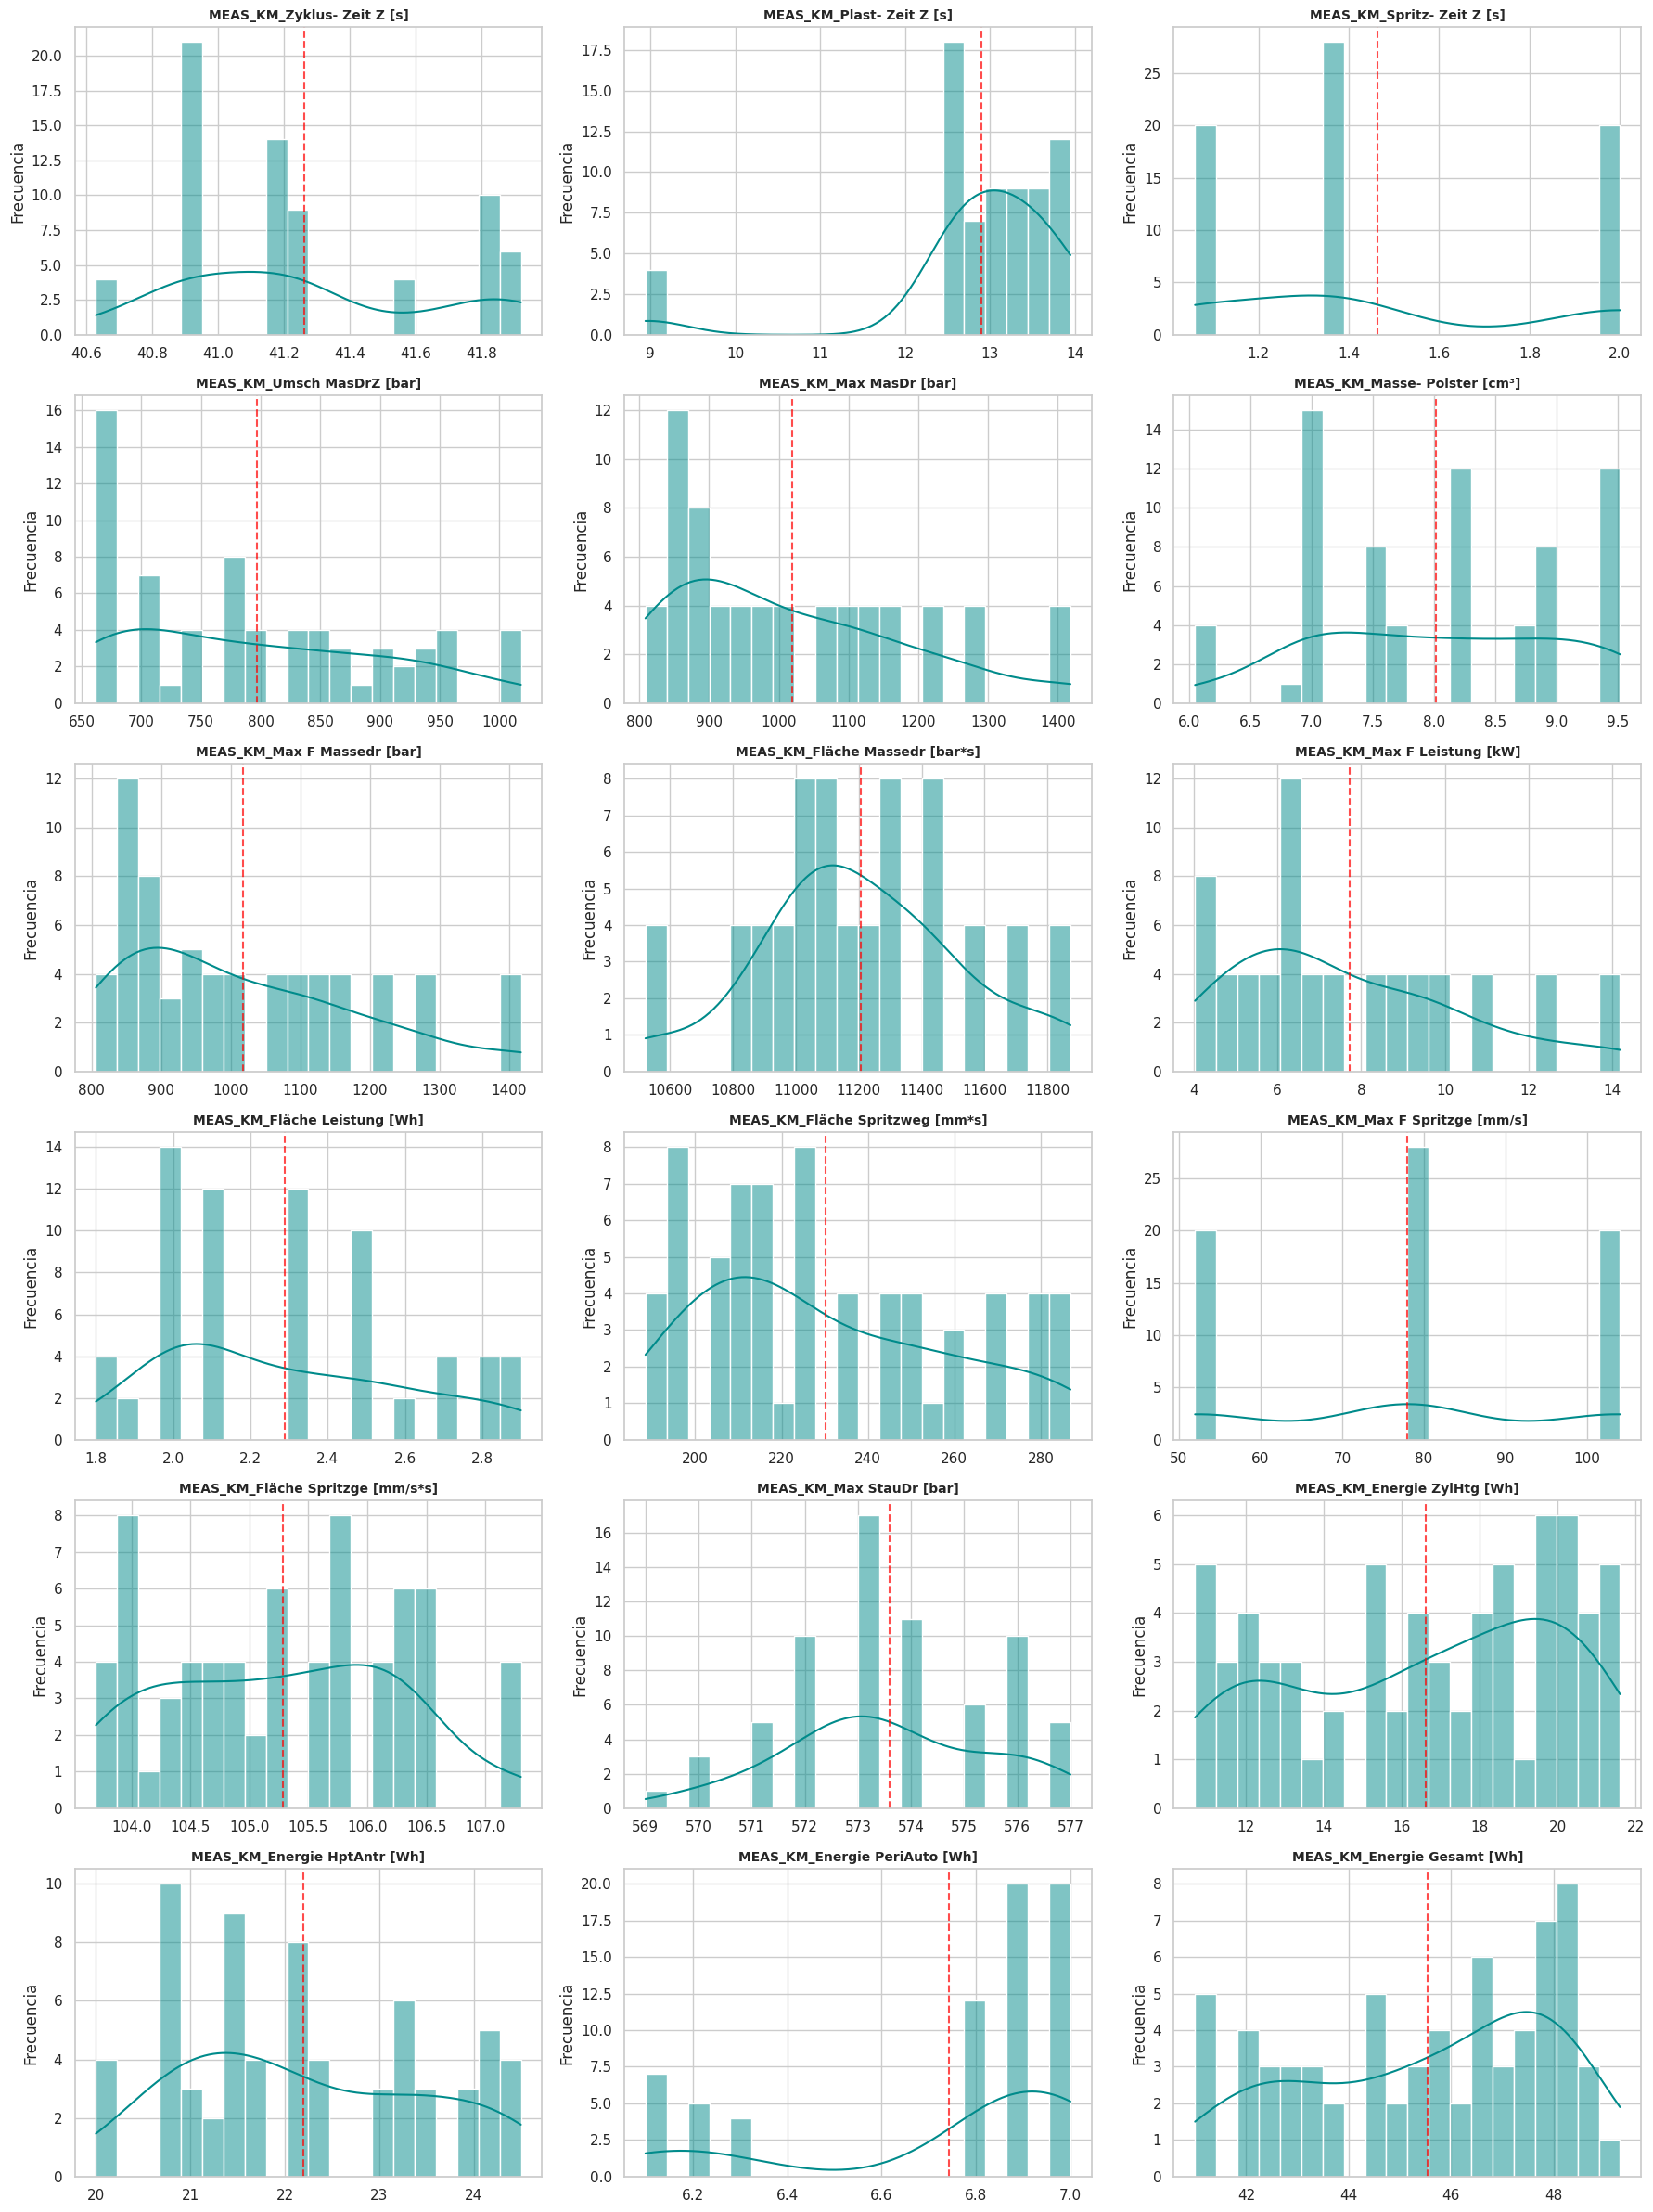

In [18]:
# 3. Visualización masiva de los targets válidos
if len(targets_validos) > 0:
    filas = math.ceil(len(targets_validos) / 3)
    fig, axes = plt.subplots(filas, 3, figsize=(18, 4 * filas))
    axes = axes.flatten()

    for i, col in enumerate(targets_validos):
        sns.histplot(df_quality[col], bins=20, kde=True, ax=axes[i], color='darkcyan')
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frecuencia')

        # Línea de la media
        axes[i].axvline(df_quality[col].mean(), color='red', linestyle='--', alpha=0.7)

    # Limpiamos los subplots sobrantes si la grilla no es exacta
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Análisis de Distribución de las Variables Objetivo (**df_quality**)

La visualización de las distribuciones a través de histogramas y la Estimación de Densidad del Kernel (KDE) permite caracterizar el comportamiento estadístico de las métricas de calidad y los parámetros finales del ciclo. De este análisis se desprenden las siguientes observaciones clave para la etapa de modelado:

* **Naturaleza Multimodal y Discreta:** Variables como el tiempo de inyección (`MEAS_KM_Spritz-Zeit Z [s]`) o la velocidad máxima (`MEAS_KM_Max F Spritzge [mm/s]`) presentan distribuciones con picos claramente separados (multimodalidad). Esto refleja la naturaleza del Diseño de Experimentos (DoE), donde los parámetros de la máquina inyectora no variaron de forma continua, sino en configuraciones discretas correspondientes a los 17 escenarios evaluados.
* **Evaluación de Normalidad y Asimetría:** Varias métricas, como el consumo de energía total (`MEAS_KM_Energie Gesamt [Wh]`), exhiben asimetría (*skewness*) alejándose de una distribución normal perfecta. Esta observación justifica la necesidad de aplicar técnicas de escalamiento rigurosas (e.g., estandarización) en la **fase de modelado**, garantizando así la estabilidad numérica y la convergencia de los algoritmos basados en gradientes (FCN, CNN-LSTM).
* **Ausencia de Valores Atípicos Extremos:** Las distribuciones muestran que el proceso industrial se mantuvo dentro de rangos operativos lógicos para la resina utilizada, sin la presencia de *outliers* severos que requieran una eliminación destructiva de los registros.

### Visualización de datos de sensores

A fin de entender las series con las que trabajamos, visualizamoos una de las curvas de presion de los experimentos realizados. En las máquinas de inyeccipon de plastico, un ciclo va desde la inyección del plastico por el tornillo de la maquina hasta que el producto de (ABS, etx) se solidifica y es retirado para comenzar con la segunda pieza, etc. Para entender mejor este proceso puede ir a los siguentes enlaces:

https://www.youtube.com/watch?v=b1U9W4iNDiQ

https://www.youtube.com/shorts/eN0WDpE4jbg

https://www.youtube.com/watch?v=FraGCo1ZwzI

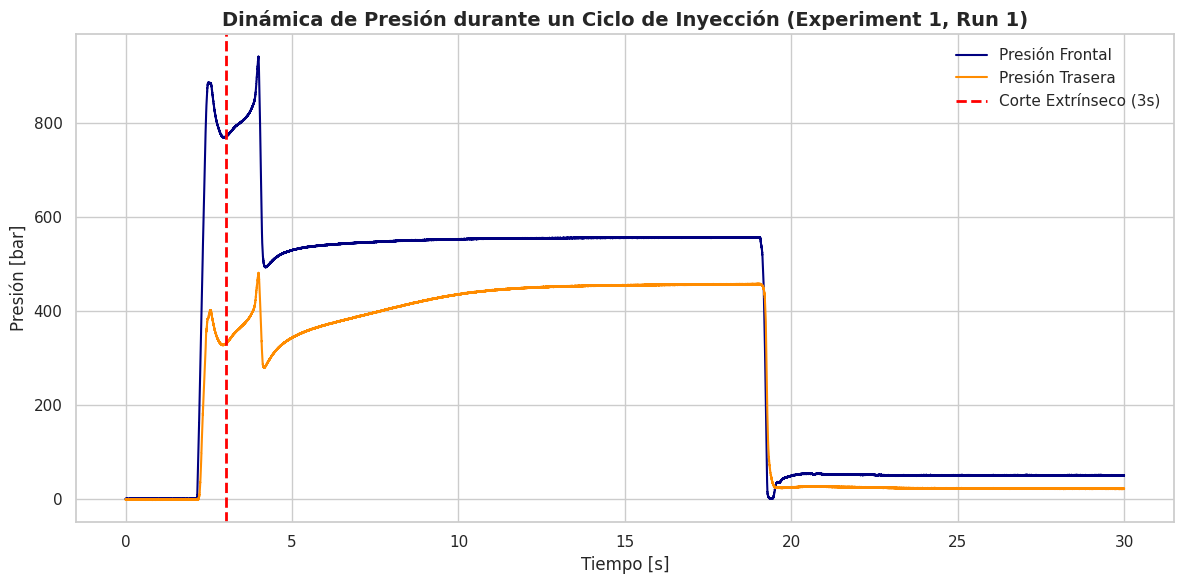

In [19]:
# ==============================================================================
# Visualización de un ciclo de inyección completo
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filtramos un único experimento y su primera corrida
ejemplo_ciclo = df_pressure[(df_pressure['META_experiment'] == 1) & (df_pressure['META_run'] == 1)]

plt.figure(figsize=(12, 6))
# Graficamos la presión frontal
sns.lineplot(x='Time[s]', y='MEAS_pressure_frontsensor_bar', data=ejemplo_ciclo, label='Presión Frontal', color='navy')
# Graficamos la presión trasera
sns.lineplot(x='Time[s]', y='MEAS_pressure_backsensor_bar', data=ejemplo_ciclo, label='Presión Trasera', color='darkorange')

# --- NUEVA LÍNEA: Corte de los 3 segundos ---
plt.axvline(x=3, color='red', linestyle='--', linewidth=2, label='Corte Extrínseco (3s)')
# --------------------------------------------

plt.title('Dinámica de Presión durante un Ciclo de Inyección (Experiment 1, Run 1)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo [s]', fontsize=12)
plt.ylabel('Presión [bar]', fontsize=12)

# Colocamos la leyenda
plt.legend()
plt.tight_layout()

# Guardamos el gráfico en la carpeta results (Requisito de la rúbrica)
os.makedirs('results', exist_ok=True)
plt.savefig('results/eda_ciclo_inyeccion_con_corte.png', dpi=300)
plt.show()

In [20]:
# observamos otro de los experimentos...

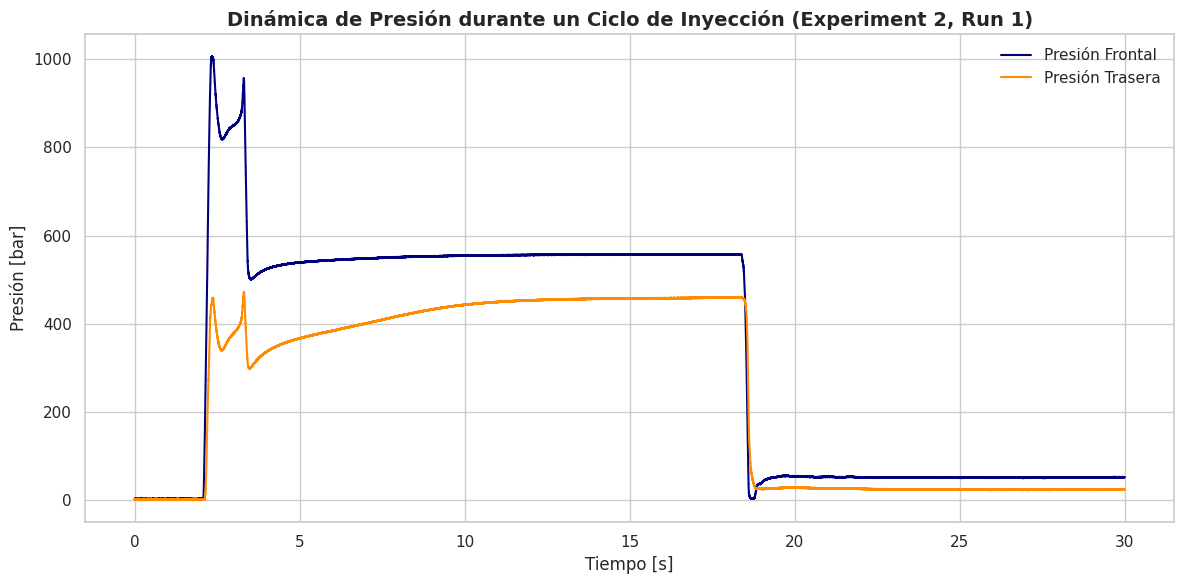

In [21]:
# ==============================================================================
# Visualización de un ciclo de inyección completo
# ==============================================================================
# Filtramos un único experimento y su primera corrida
ejemplo_ciclo = df_pressure[(df_pressure['META_experiment'] == 2) & (df_pressure['META_run'] == 1)]

plt.figure(figsize=(12, 6))
# Graficamos la presión frontal
sns.lineplot(x='Time[s]', y='MEAS_pressure_frontsensor_bar', data=ejemplo_ciclo, label='Presión Frontal', color='navy')
# Graficamos la presión trasera
sns.lineplot(x='Time[s]', y='MEAS_pressure_backsensor_bar', data=ejemplo_ciclo, label='Presión Trasera', color='darkorange')

plt.title('Dinámica de Presión durante un Ciclo de Inyección (Experiment 2, Run 1)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo [s]', fontsize=12)
plt.ylabel('Presión [bar]', fontsize=12)
plt.legend()
plt.tight_layout()

 Variabilidad Inter-Experimento: La Huella Dinámica

Al contrastar gráficamente corridas pertenecientes a distintos experimentos (e.g., Experimento 1 vs. Experimento 2), se evidencia una notable variación en la morfología y amplitud de las curvas de presión.

*   **Sensibilidad a los Parámetros de Control:** Las variaciones en la presión máxima alcanzada (superando los 1000 bar en ciertos escenarios) y los cambios en la concavidad de la fase transitoria demuestran que el sistema físico es altamente sensible a las configuraciones establecidas en el Diseño de Experimentos.
*   **Justificación del Modelo Predictivo:** Esta marcada diferencia entre experimentos es exactamente la "huella digital" que el modelo sustituto debe aprender a decodificar. La variabilidad observada confirma que los primeros segundos del ciclo contienen información discriminativa suficiente para inferir bajo qué configuración está operando la máquina y, por ende, predecir las métricas de calidad finales.

Visualizamos todos los casos, viendo cada experimento a fin de entender mejor el comportamiento de los datos, notamos que las curvas para los experimentos son bastante similares, esto debido a que por lo general las maquinas de inyección trabajan por ciclos fabricando piezas identicas. Al menos en este dataset solo se tenía un molde para hacer los experimentos. Se nota como la Presion "Bar" varia a medida que cambian los paramaetros de df_quality, se nota mayor diferencia entre experimentos.

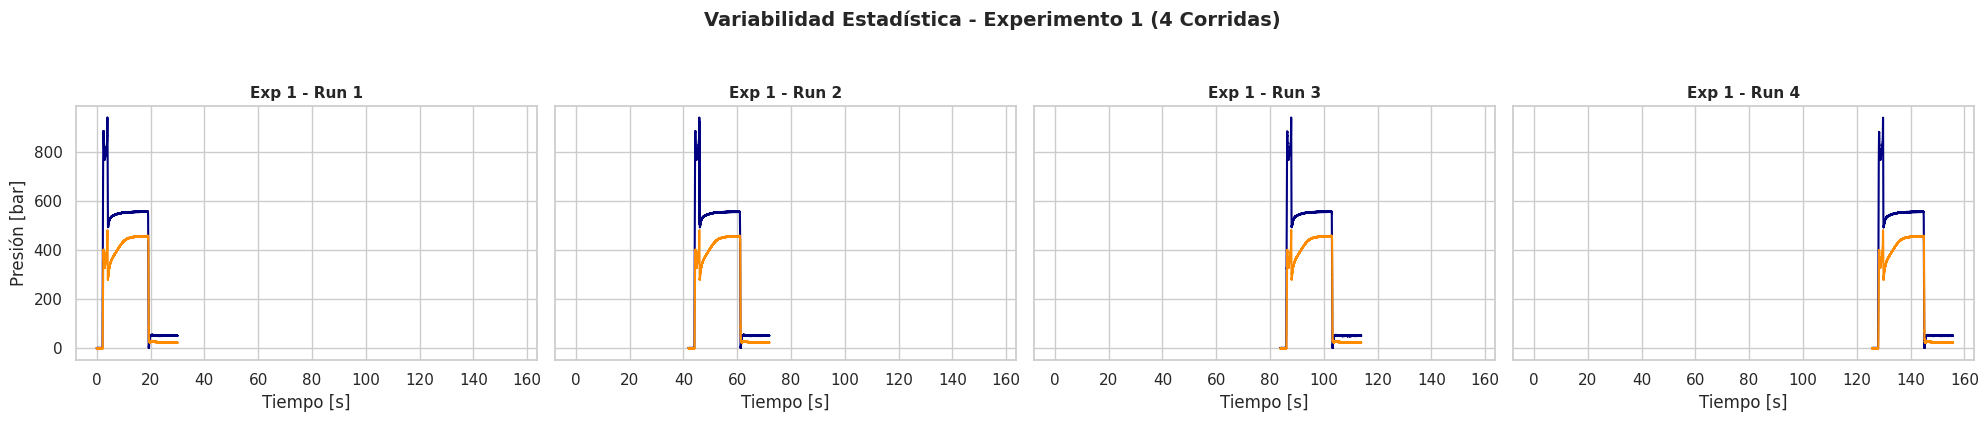

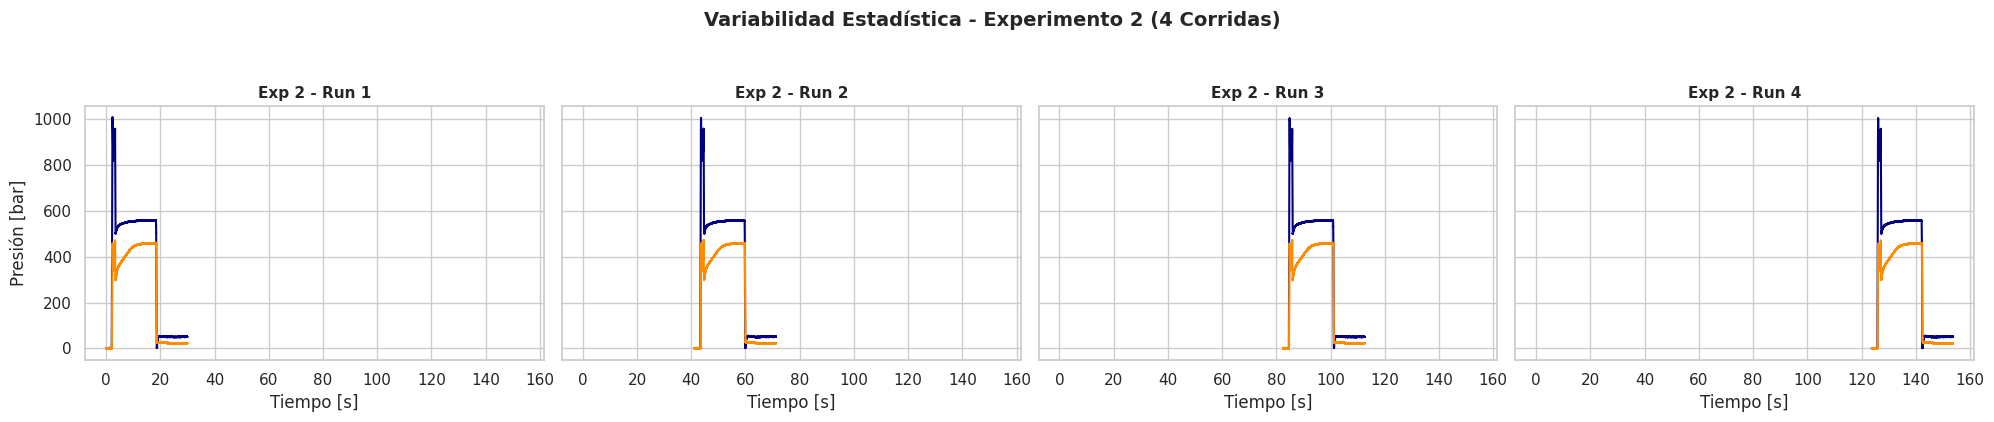

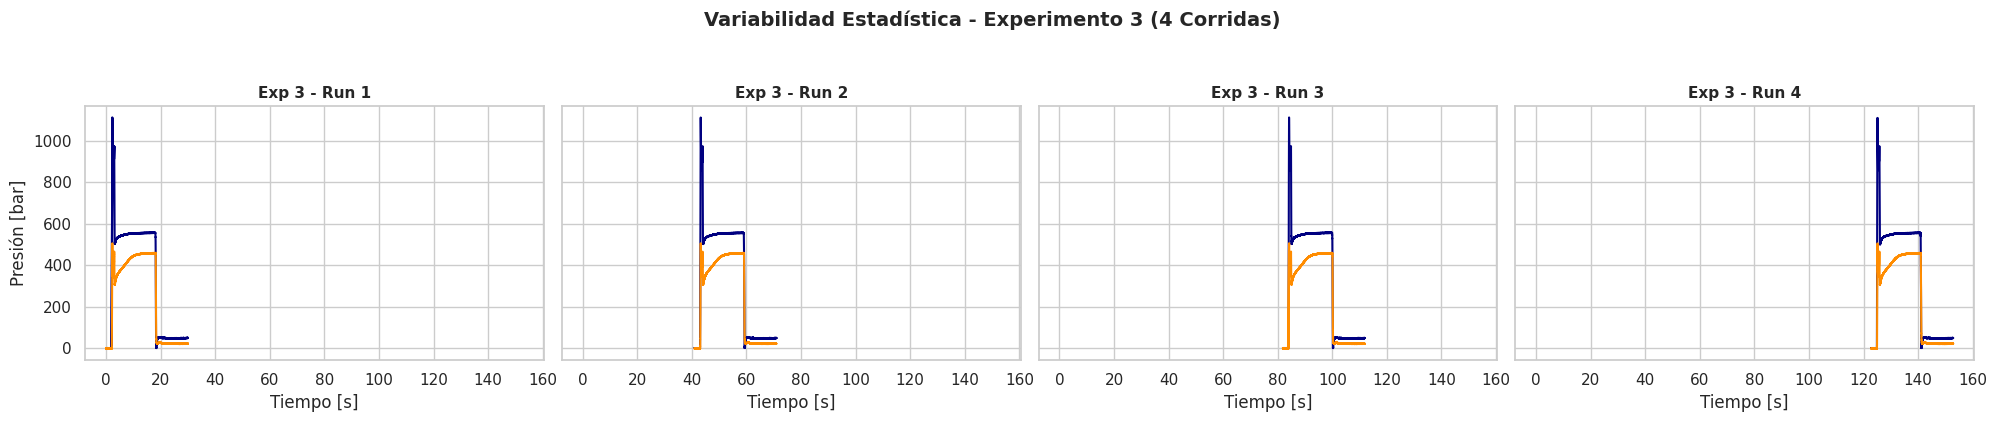

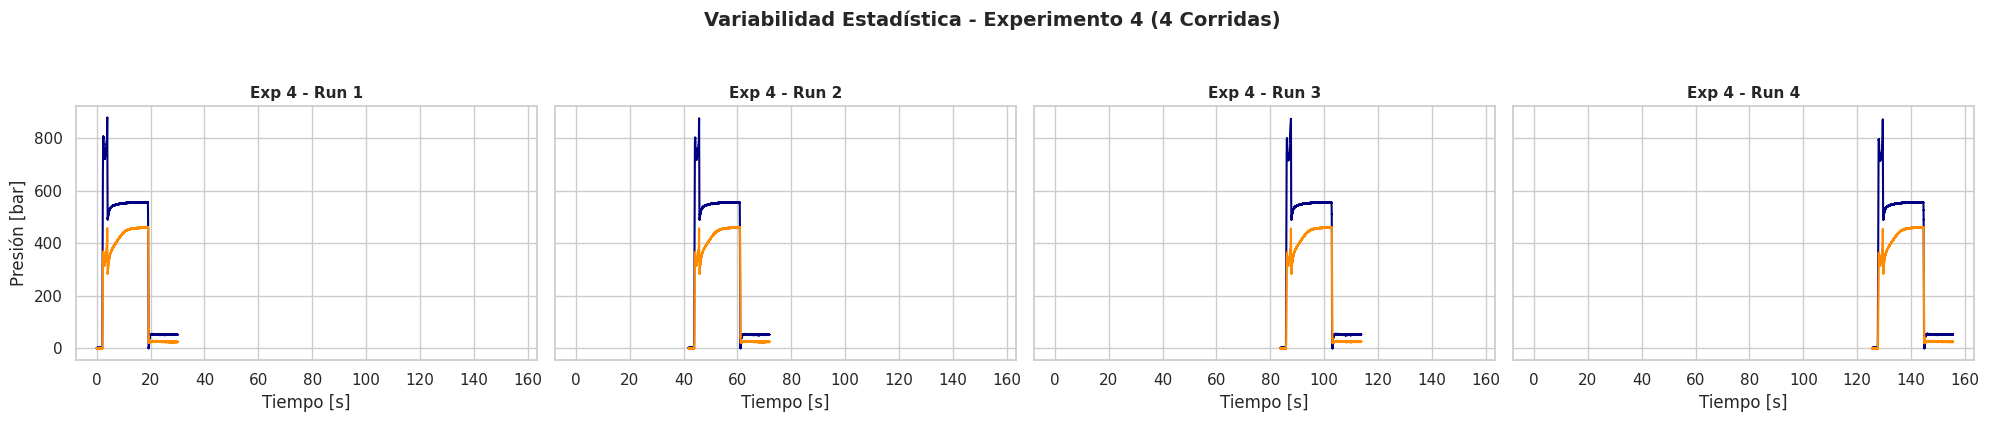

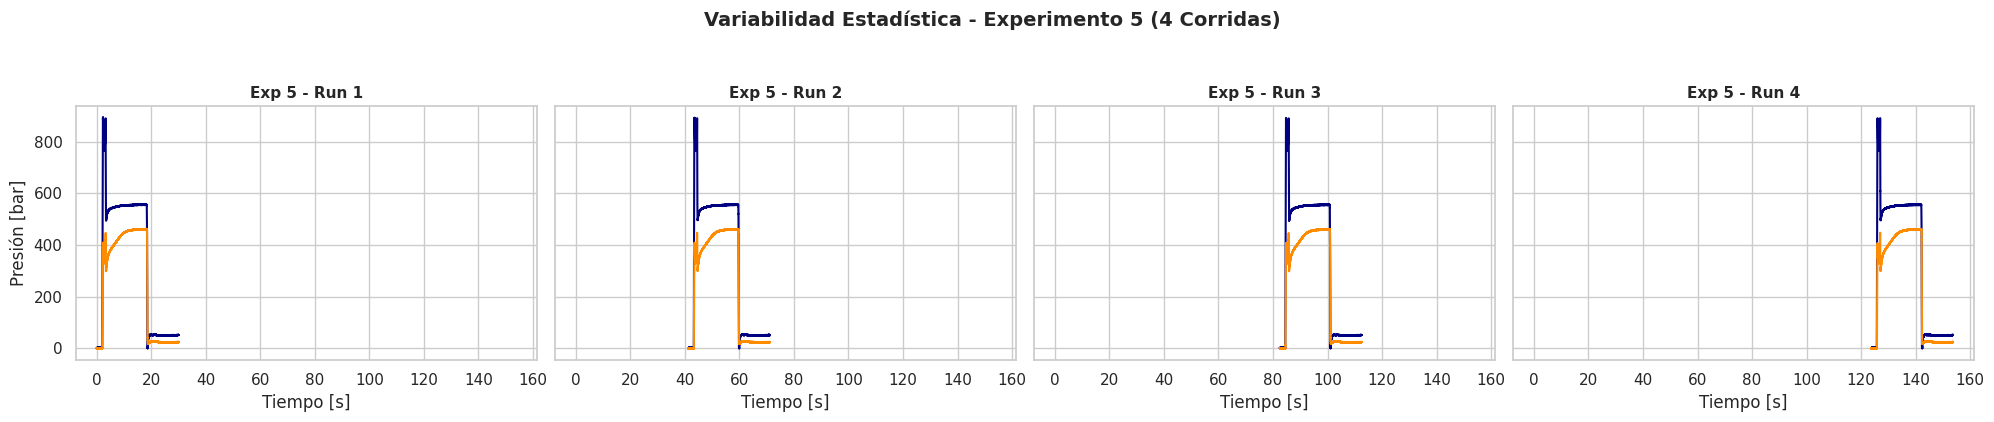

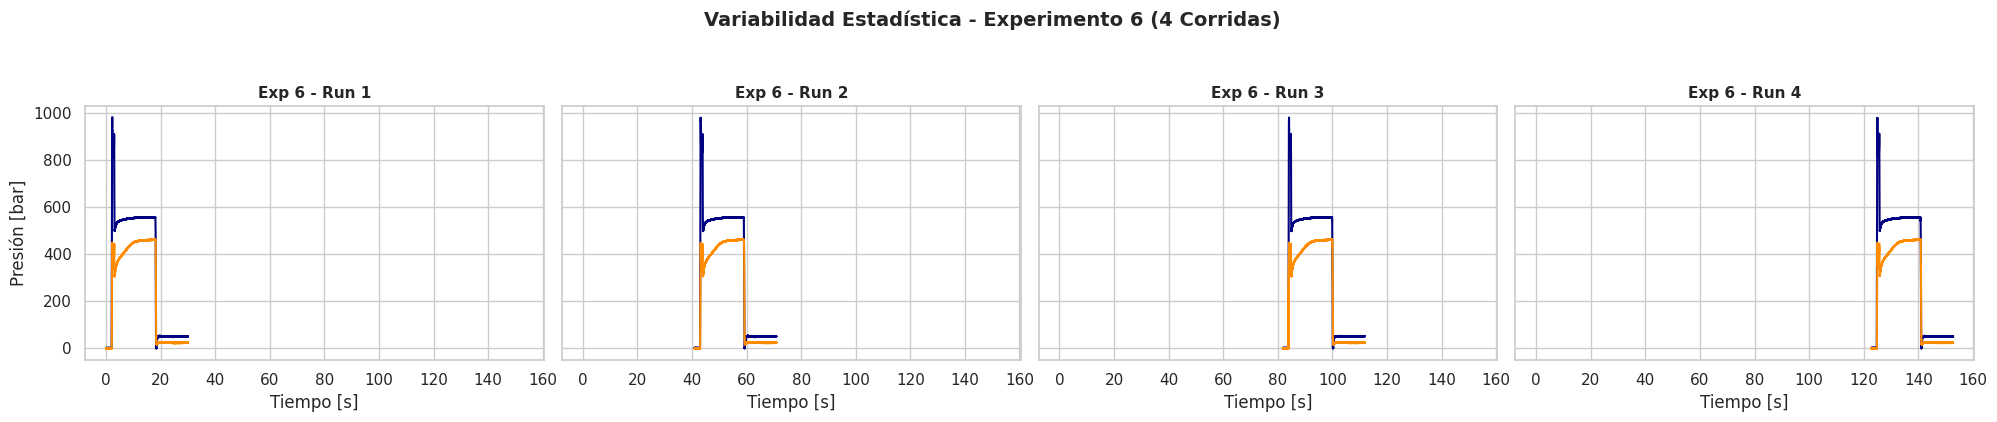

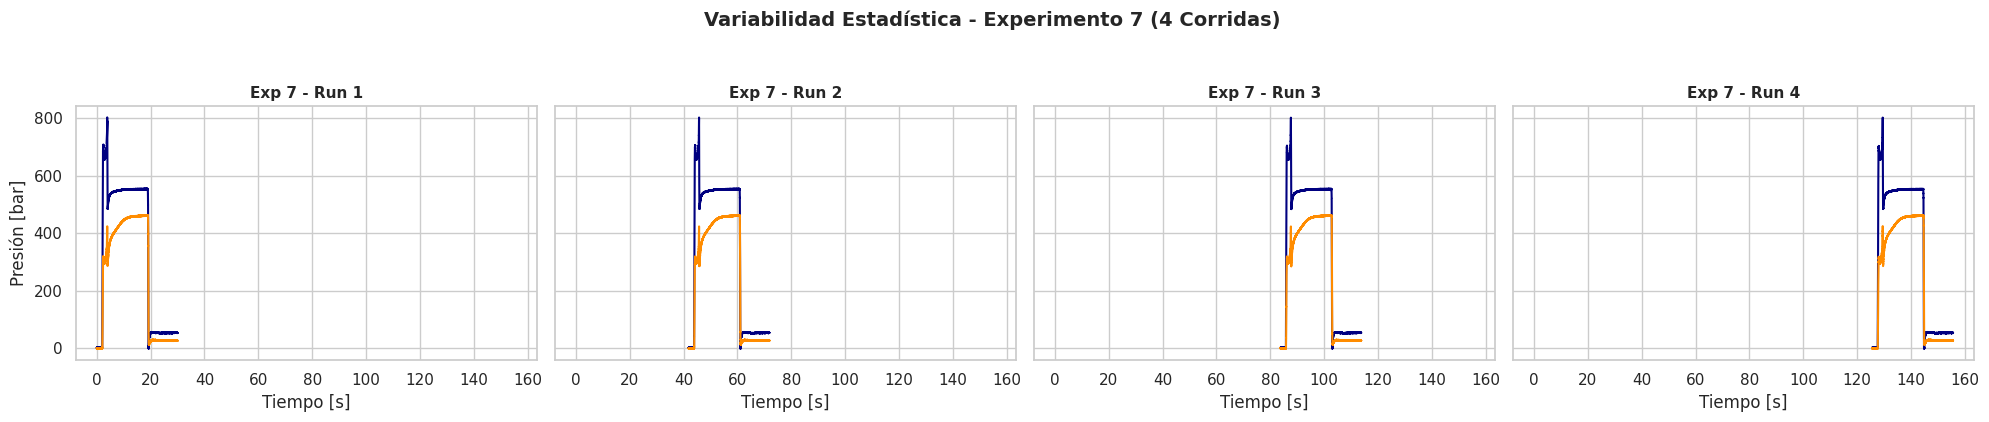

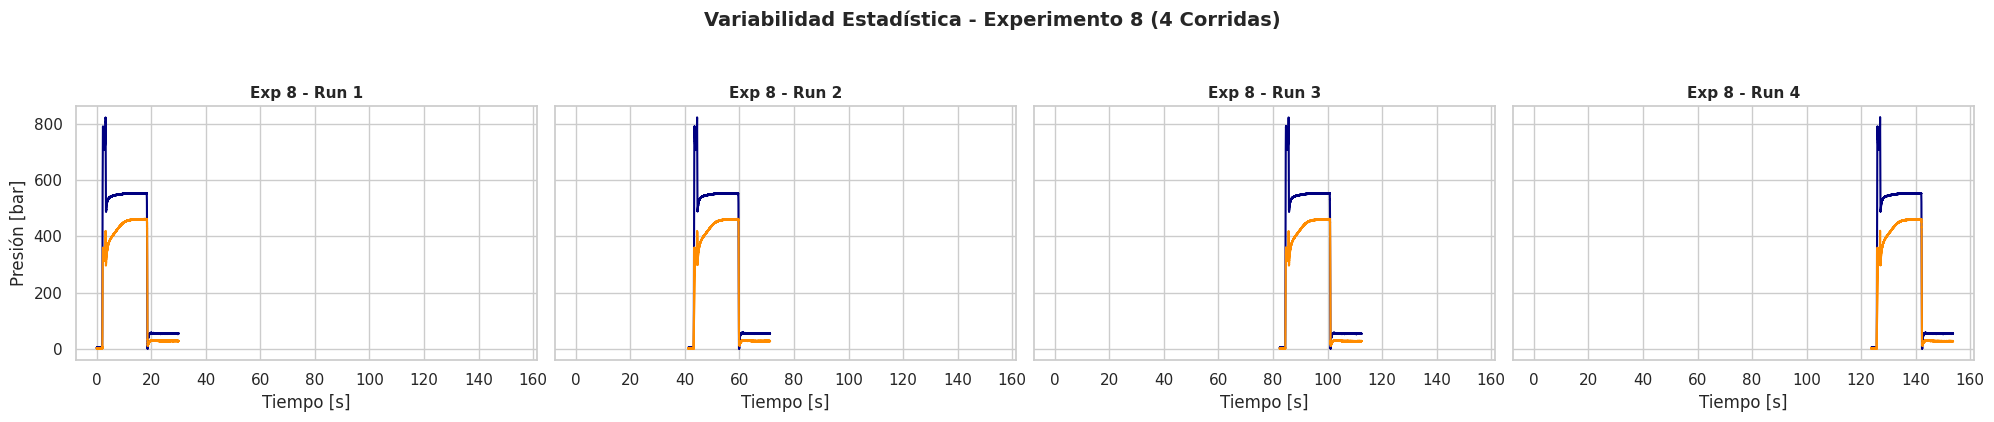

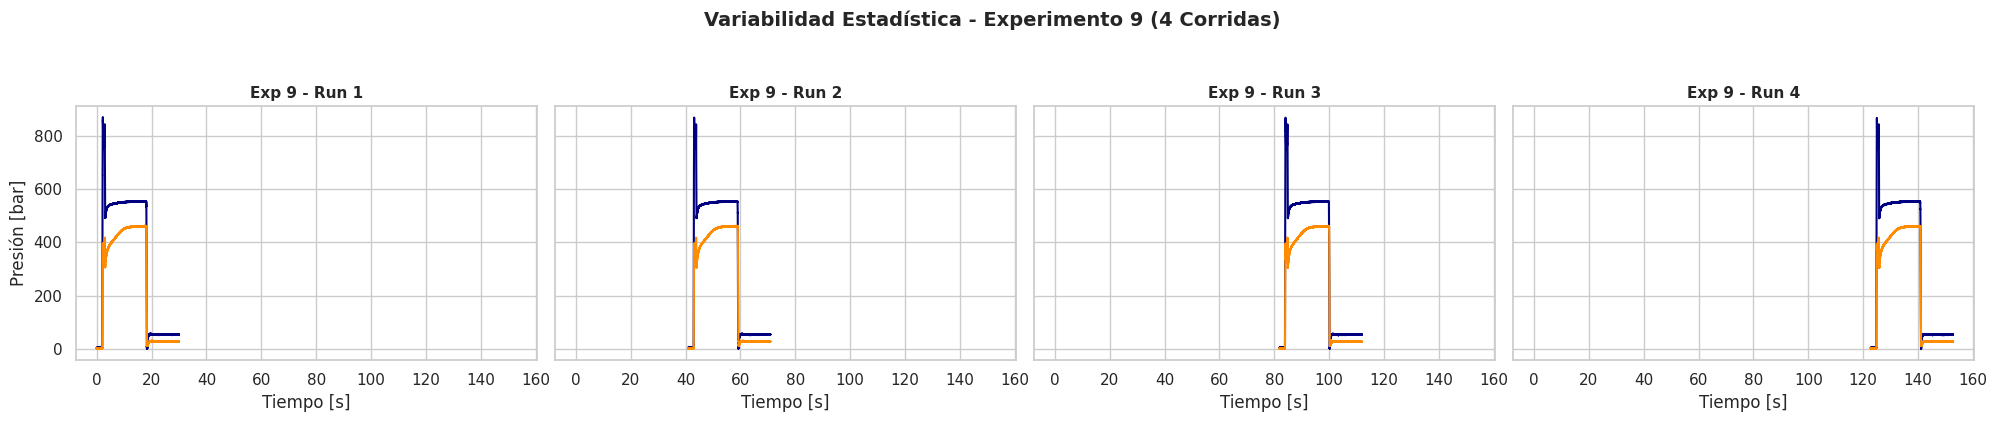

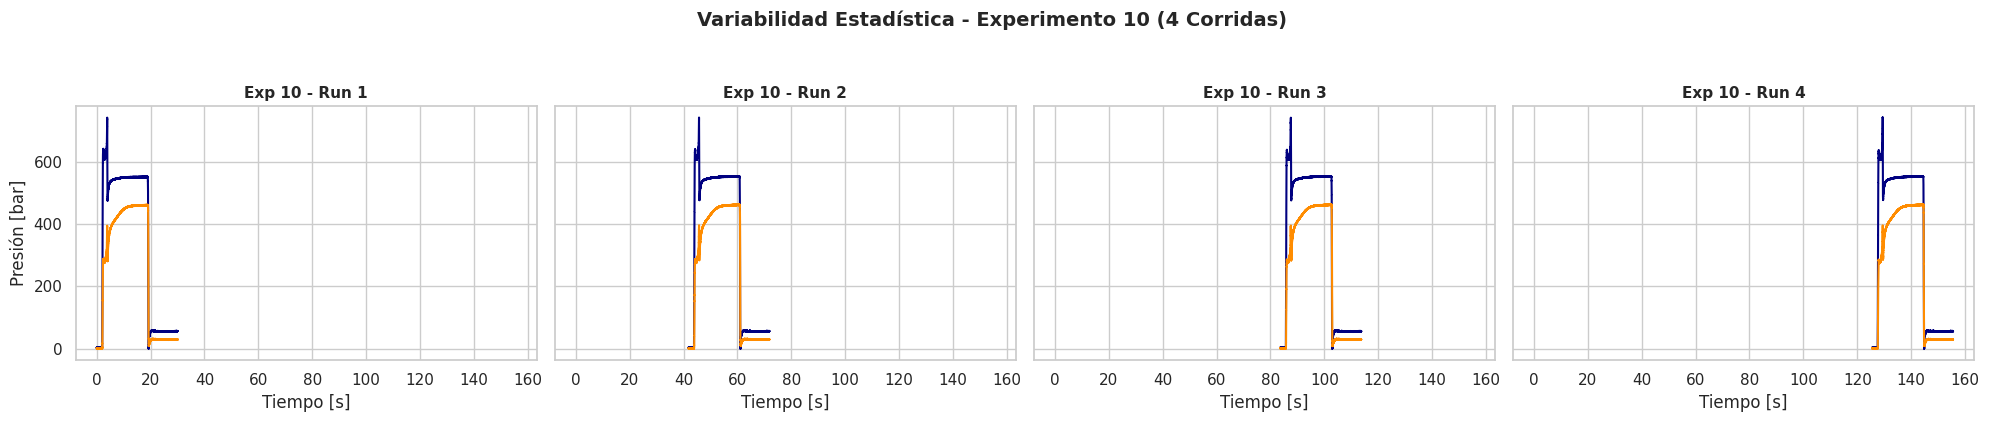

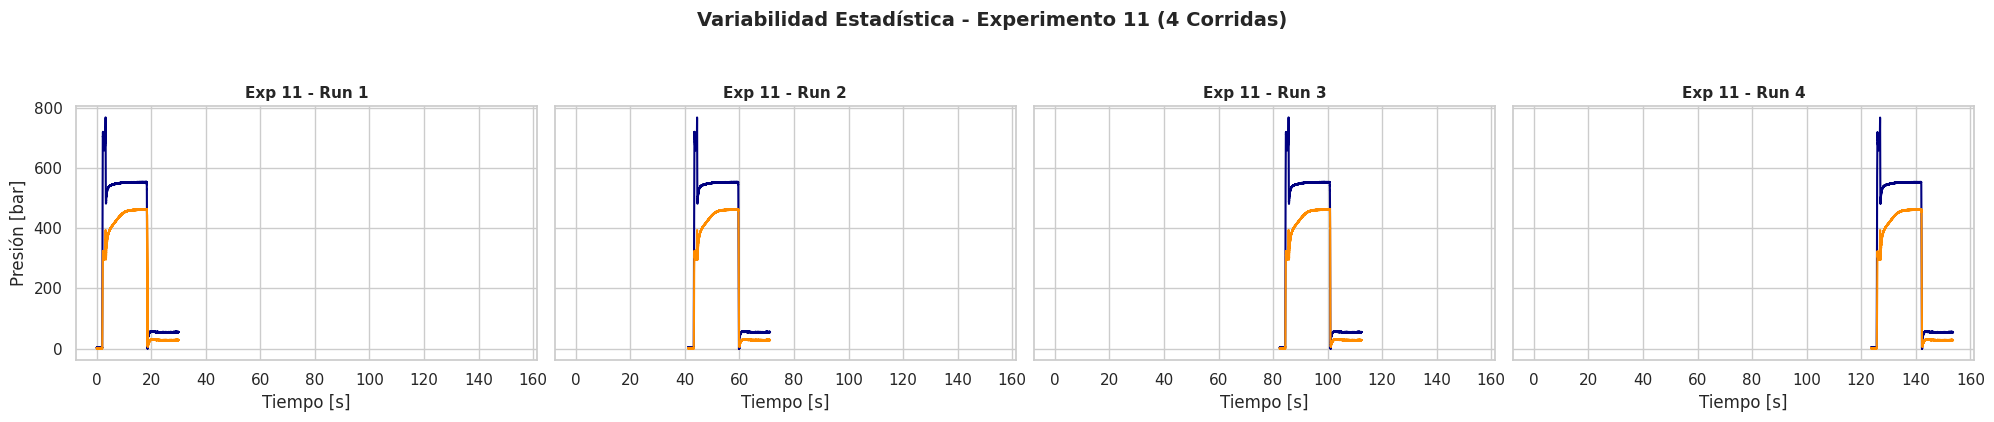

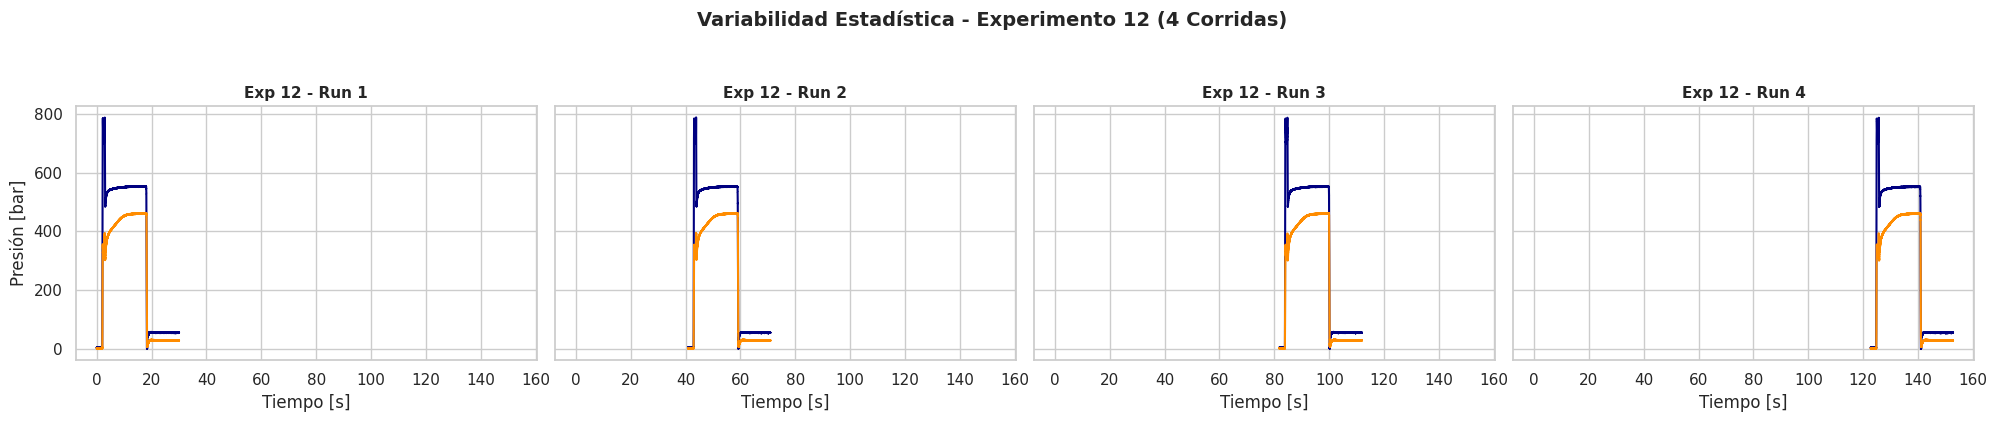

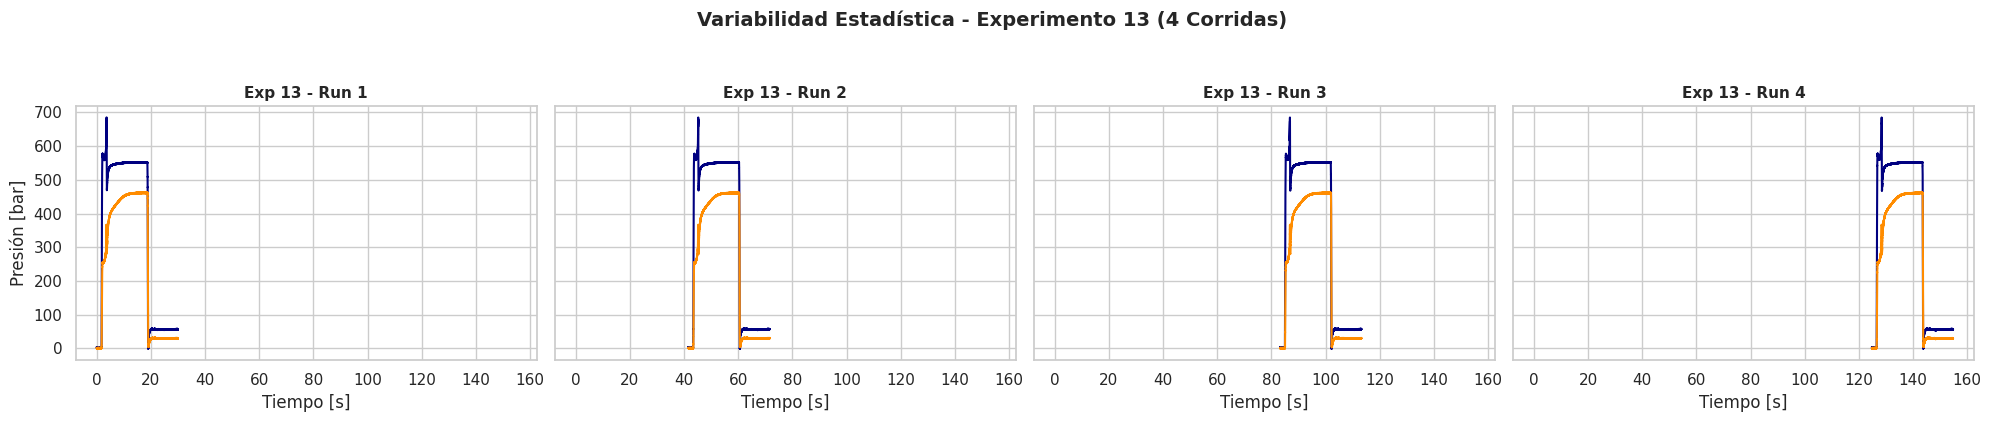

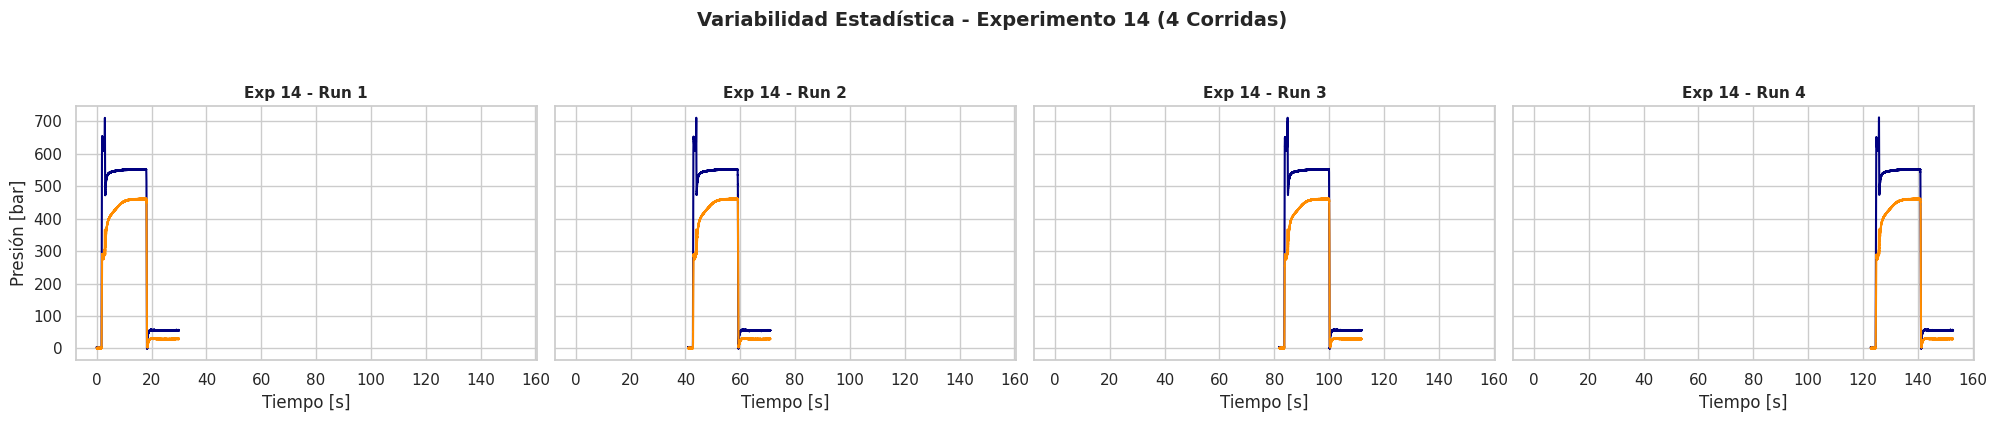

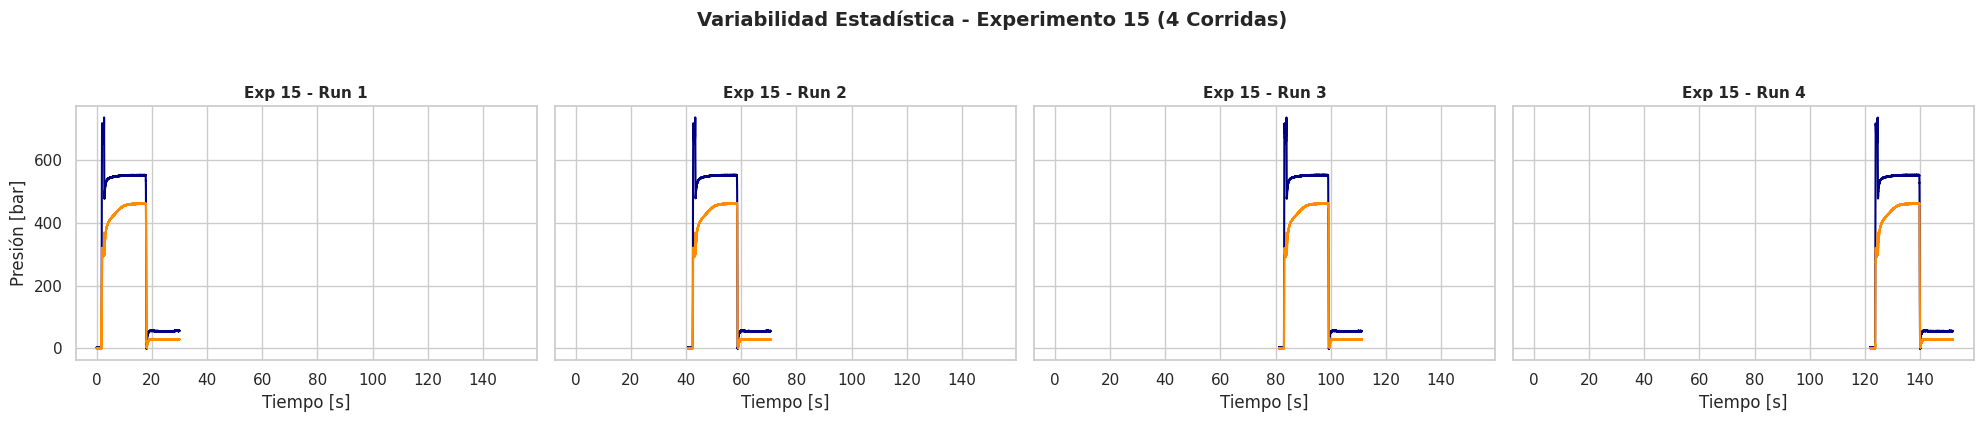

In [22]:
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Visualización Limpia (Las 4 Corridas por cada Experimento en Filas Separadas)
# ==============================================================================
experimentos_unicos = sorted(df_pressure['META_experiment'].unique())

for exp_id in experimentos_unicos:
    # Filtramos las 4 corridas de este experimento específico
    datos_exp = df_pressure[df_pressure['META_experiment'] == exp_id]
    runs_disponibles = sorted(datos_exp['META_run'].unique())

    # Creamos una figura horizontal de 1 fila x 4 columnas para este experimento
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)

    for i, run_id in enumerate(runs_disponibles):
        datos_run = datos_exp[datos_exp['META_run'] == run_id]

        if not datos_run.empty:
            sns.lineplot(x='Time[s]', y='MEAS_pressure_frontsensor_bar', data=datos_run, ax=axes[i], color='navy')
            sns.lineplot(x='Time[s]', y='MEAS_pressure_backsensor_bar', data=datos_run, ax=axes[i], color='darkorange')

        axes[i].set_title(f'Exp {exp_id} - Run {run_id}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Tiempo [s]')
        axes[i].set_ylabel('Presión [bar]' if i == 0 else '')
        axes[i].grid(True)

    plt.suptitle(f'Variabilidad Estadística - Experimento {exp_id} (4 Corridas)', fontsize=14, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

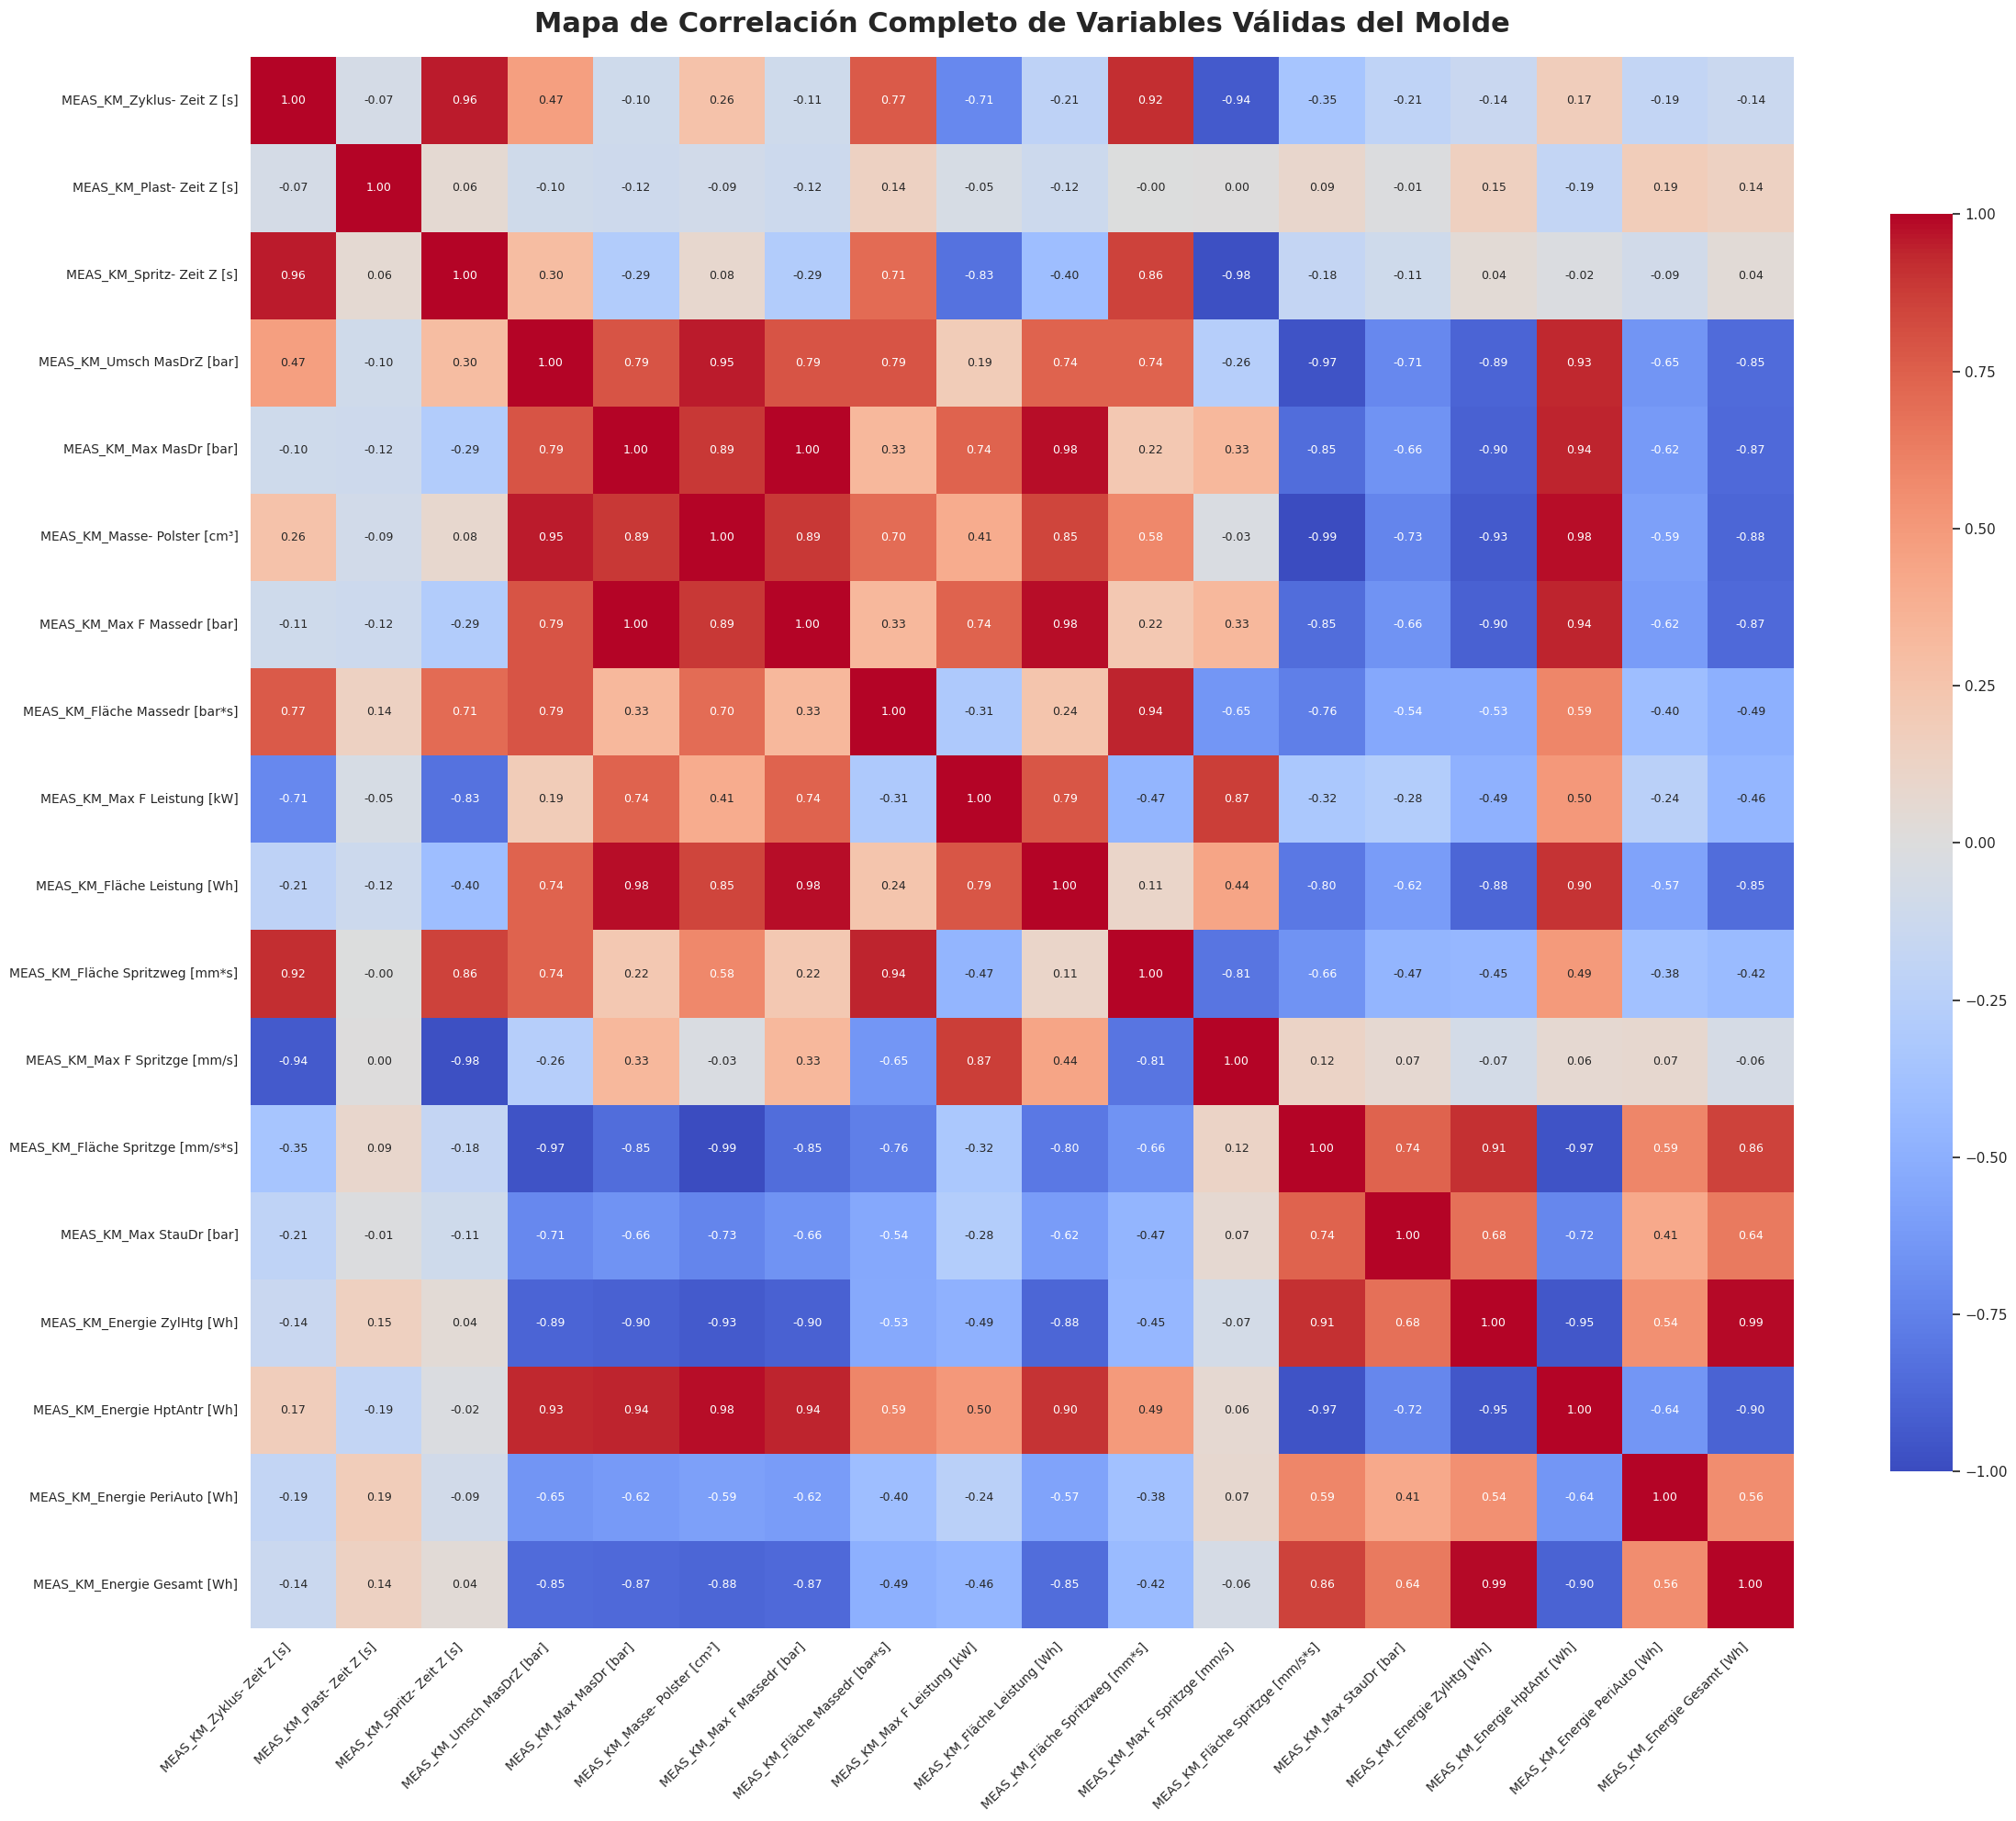

In [23]:
# ==============================================================================
# Mapa de Correlaciones (Vista Completa)
# ==============================================================================
# Utilizamos la lista de 'targets_validos' generada previamente (18 variables)
corr_matrix_full = df_quality[targets_validos].corr()

# Forzamos una figura muy grande para acomodar todas las variables sin que el texto colapse
plt.figure(figsize=(24, 20))

# Usamos annot_kws={"size": 9} para achicar los números internos
sns.heatmap(corr_matrix_full,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            vmin=-1,
            vmax=1,
            annot_kws={"size": 9},
            cbar_kws={'shrink': 0.8}) # Ajusta el tamaño de la barra de color

plt.title('Mapa de Correlación Completo de Variables Válidas del Molde', fontsize=22, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Guardamos el gráfico completo
plt.savefig('results/eda_correlacion_completa.png', dpi=300, bbox_inches='tight')
plt.show()

### Mapa de Correlación: Interdependencia y Multicolinealidad en las Variables Objetivo

En base al mapa de correlación (heatmap) sobre los 18 *targets* filtrados del conjunto de calidad permite extraer algunas conclusiones clave antes de interpretar los resultados de los modelos:

*   **Identificación de Multicolinealidad (Redundancia):** Se observan bloques de alta correlación positiva (tonos rojos intensos, cercanas a 1.0) y negativa (tonos azules oscuros, cercanas a -1.0). Por ejemplo, es esperable que las distintas métricas de consumo energético o los tiempos de fase estén fuertemente ligados entre sí. Esto indica que muchas de estas 18 variables contienen información redundante.
*   **Validación de la Coherencia Física:** Las relaciones evidenciadas en el mapa validan empíricamente el comportamiento termodinámico y mecánico del proceso de moldeo por inyección. Las variables operan bajo principios físicos acoplados (e.g., a mayor presión, mayor requerimiento energético de los actuadores), lo cual se refleja claramente en los coeficientes de correlación de Pearson.
*   **Contexto para la Evaluación del Modelo:** Entender estas dependencias es crucial para la fase de evaluación. Si el modelo predictivo (FCN o CNN-LSTM) comete un error al inferir una variable específica, es altamente probable que ese error se propague a las variables fuertemente correlacionadas con ella. Esto justifica un análisis de métricas de error (como el RMSE o MAE) de forma agrupada por clústers de comportamiento físico, en lugar de evaluar cada *target* en el vacío.

In [24]:
import numpy as np
import pandas as pd

# ==============================================================================
# CELDA: Filtrado Automático de Variables Objetivo (Targets) por Colinealidad
# ==============================================================================

# 1. Definimos las 18 variables válidas iniciales (sin varianza cero)
targets_iniciales = [
    'MEAS_KM_Zyklus- Zeit Z [s]', 'MEAS_KM_Plast- Zeit Z [s]', 'MEAS_KM_Spritz- Zeit Z [s]',
    'MEAS_KM_Umsch MasDrZ [bar]', 'MEAS_KM_Max MasDr [bar]', 'MEAS_KM_Masse- Polster [cm³]',
    'MEAS_KM_Max F Massedr [bar]', 'MEAS_KM_Fläche Massedr [bar*s]', 'MEAS_KM_Max F Leistung [kW]',
    'MEAS_KM_Fläche Leistung [Wh]', 'MEAS_KM_Fläche Spritzweg [mm*s]', 'MEAS_KM_Max F Spritzge [mm/s]',
    'MEAS_KM_Fläche Spritzge [mm/s*s]', 'MEAS_KM_Max StauDr [bar]', 'MEAS_KM_Energie ZylHtg [Wh]',
    'MEAS_KM_Energie HptAntr [Wh]', 'MEAS_KM_Energie PeriAuto [Wh]', 'MEAS_KM_Energie Gesamt [Wh]'
]

df_targets = df_quality[targets_iniciales]

# 2. Calculamos la matriz de correlación absoluta de Pearson
corr_matrix = df_targets.corr().abs()

# 3. Seleccionamos el triángulo superior de la matriz de correlación
# (Esto evita eliminar ambas variables que están correlacionadas entre sí)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Establecemos el umbral de redundancia (0.90 es el estándar industrial)
umbral_correlacion = 0.90

# 5. Encontramos las columnas que superan el umbral para ser eliminadas
targets_a_eliminar = [column for column in upper_tri.columns if any(upper_tri[column] > umbral_correlacion)]

# 6. Filtramos y creamos la lista final de targets independientes
targets_finales_automaticos = [col for col in targets_iniciales if col not in targets_a_eliminar]

print(f"Total de targets iniciales: {len(targets_iniciales)}")
print(f"Targets eliminados por alta correlación (> {umbral_correlacion}): {len(targets_a_eliminar)}")
print(f"Total de targets finales para el modelo: {len(targets_finales_automaticos)}\n")

print("Lista definitiva de Targets:")
for t in targets_finales_automaticos:
    print(f"- {t}")

# Creamos el dataframe final que usaremos en las siguientes etapas
df_quality_filtrado = df_quality[targets_finales_automaticos]

Total de targets iniciales: 18
Targets eliminados por alta correlación (> 0.9): 10
Total de targets finales para el modelo: 8

Lista definitiva de Targets:
- MEAS_KM_Zyklus- Zeit Z [s]
- MEAS_KM_Plast- Zeit Z [s]
- MEAS_KM_Umsch MasDrZ [bar]
- MEAS_KM_Max MasDr [bar]
- MEAS_KM_Fläche Massedr [bar*s]
- MEAS_KM_Max F Leistung [kW]
- MEAS_KM_Max StauDr [bar]
- MEAS_KM_Energie PeriAuto [Wh]


In [25]:
targets_seleccionados = [
    'MEAS_KM_Zyklus- Zeit Z [s]',
    'MEAS_KM_Plast- Zeit Z [s]',
    'MEAS_KM_Umsch MasDrZ [bar]',
    'MEAS_KM_Max MasDr [bar]',
    'MEAS_KM_Fläche Massedr [bar*s]',
    'MEAS_KM_Max F Leistung [kW]',
    'MEAS_KM_Max StauDr [bar]',
    'MEAS_KM_Energie PeriAuto [Wh]'
]


### SELECCIÓN DE TARGETS MULTI-OUTPUT


In [26]:
print("--- ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES OBJETIVO ---")
# Usamos la lista de targets seleccionados
print(df_quality[targets_seleccionados].describe())

--- ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES OBJETIVO ---
       MEAS_KM_Zyklus- Zeit Z [s]  MEAS_KM_Plast- Zeit Z [s]  \
count                   68.000000                  68.000000   
mean                    41.261618                  12.895294   
std                      0.392891                   1.094774   
min                     40.630000                   8.940000   
25%                     40.920000                  12.640000   
50%                     41.210000                  13.140000   
75%                     41.570000                  13.510000   
max                     41.920000                  13.950000   

       MEAS_KM_Umsch MasDrZ [bar]  MEAS_KM_Max MasDr [bar]  \
count                   68.000000                68.000000   
mean                   797.147059              1018.970588   
std                    108.844304               169.005694   
min                    662.000000               809.000000   
25%                    705.000000               882.000

In [27]:
print("Ciclos únicos en sensores de presión:", df_pressure[['META_experiment', 'META_run']].drop_duplicates().shape[0])
print("Ciclos únicos en metas de calidad:", df_quality[['META_experiment', 'META_run']].drop_duplicates().shape[0])

Ciclos únicos en sensores de presión: 60
Ciclos únicos en metas de calidad: 68


In [28]:
# ==============================================================================
# AUDITORÍA DE TIPOS DE DATOS Y MUESTRAS CRUDAS
# ==============================================================================
print("--- TIPOS DE DATOS (DTYPES) ---")
print("df_pressure:")
print(df_pressure[['META_experiment', 'META_run']].dtypes)

print("\ndf_quality:")
print(df_quality[['META_experiment', 'META_run']].dtypes)

print("\n--- INSPECCIÓN VISUAL DE LOS PRIMEROS REGISTROS ---")
# Usamos .values para ver el formato crudo (raw array) sin el maquillaje de Pandas
print("df_pressure crudo (primeras 3 filas):")
print(df_pressure[['META_experiment', 'META_run']].head(3).values)

print("\ndf_quality crudo (primeras 3 filas):")
print(df_quality[['META_experiment', 'META_run']].head(3).values)

print("\n--- BÚSQUEDA DE VALORES NULOS EN LAS LLAVES ---")
print("Nulos en df_pressure:", df_pressure[['META_experiment', 'META_run']].isnull().sum().to_dict())
print("Nulos en df_quality:", df_quality[['META_experiment', 'META_run']].isnull().sum().to_dict())

--- TIPOS DE DATOS (DTYPES) ---
df_pressure:
META_experiment    int64
META_run           int32
dtype: object

df_quality:
META_experiment    int64
META_run           int64
dtype: object

--- INSPECCIÓN VISUAL DE LOS PRIMEROS REGISTROS ---
df_pressure crudo (primeras 3 filas):
[[1 1]
 [1 1]
 [1 1]]

df_quality crudo (primeras 3 filas):
[[1 1]
 [1 2]
 [1 3]]

--- BÚSQUEDA DE VALORES NULOS EN LAS LLAVES ---
Nulos en df_pressure: {'META_experiment': 0, 'META_run': 0}
Nulos en df_quality: {'META_experiment': 0, 'META_run': 0}


In [29]:
# ==============================================================================
# AUDITORÍA AVANZADA: INTERSECCIÓN DE CONJUNTOS (SETS)
# ==============================================================================
# Convertimos los pares de (META_experiment, META_run) en tuplas para usar conjuntos
pares_pressure = set(tuple(x) for x in df_pressure[['META_experiment', 'META_run']].drop_duplicates().values)
pares_quality = set(tuple(x) for x in df_quality[['META_experiment', 'META_run']].drop_duplicates().values)

print(f"Total de ciclos únicos en Pressure: {len(pares_pressure)}")
print(f"Total de ciclos únicos en Quality: {len(pares_quality)}")

# 1. Lo que sí hace match (lo que está entrando al modelo)
interseccion = pares_pressure.intersection(pares_quality)
print(f"\n Ciclos que existen en AMBOS (Intersección): {len(interseccion)}")

# 2. Lo que se está perdiendo de Pressure
solo_en_pressure = pares_pressure - pares_quality
print(f"\n Ciclos en Pressure pero NO en Quality: {len(solo_en_pressure)}")
if len(solo_en_pressure) > 0:
    print("   Ejemplos de ciclos huérfanos en Pressure (Experiment, Run):")
    # Mostramos los primeros 10 ordenados para ver el patrón
    print("  ", sorted(list(solo_en_pressure))[:10])

# 3. Lo que se está perdiendo de Quality
solo_en_quality = pares_quality - pares_pressure
print(f"\n Ciclos en Quality pero NO en Pressure: {len(solo_en_quality)}")
if len(solo_en_quality) > 0:
    print("   Ejemplos de ciclos huérfanos en Quality (Experiment, Run):")
    print("  ", sorted(list(solo_en_quality))[:10])

Total de ciclos únicos en Pressure: 60
Total de ciclos únicos en Quality: 68

 Ciclos que existen en AMBOS (Intersección): 60

 Ciclos en Pressure pero NO en Quality: 0

 Ciclos en Quality pero NO en Pressure: 8
   Ejemplos de ciclos huérfanos en Quality (Experiment, Run):
   [(np.int64(16), np.int64(1)), (np.int64(16), np.int64(2)), (np.int64(16), np.int64(3)), (np.int64(16), np.int64(4)), (np.int64(17), np.int64(1)), (np.int64(17), np.int64(2)), (np.int64(17), np.int64(3)), (np.int64(17), np.int64(4))]


In [30]:
# ==============================================================================
# CELDA 5: Preprocesamiento Multi-Output (Fusión, Truncamiento y Exportación)
# ==============================================================================
import pandas as pd
import os

print("Variables objetivo definidas:")
for t in targets_seleccionados:
    print(f" - {t}")

# 1. FUSIÓN
df_quality_subset = df_quality[['META_experiment', 'META_run'] + targets_seleccionados]

df_merged = pd.merge(
    df_pressure,
    df_quality_subset,
    on=['META_experiment', 'META_run'],
    how='inner'
)
print(f"\nDimensiones post-fusión: {df_merged.shape}")

print("\n--- 2. TRUNCAMIENTO TEMPORAL (EARLY FORECASTING) ---")
# Creamos una columna de tiempo relativo que se reinicie a 0 para cada ciclo (run)
df_merged['Relative_Time'] = df_merged.groupby(['META_experiment', 'META_run'])['Time[s]'].transform(lambda x: x - x.min())

# Umbral de corte temporal
TIEMPO_CORTE = 3.0

# Filtramos usando el nuevo tiempo relativo
df_truncated = df_merged[df_merged['Relative_Time'] <= TIEMPO_CORTE].copy()

# Eliminamos la columna auxiliar para no afectar los tensores
df_truncated = df_truncated.drop(columns=['Relative_Time'])

print(f"Registros tras truncar a los primeros {TIEMPO_CORTE}s: {df_truncated.shape}")

# Verificamos la consistencia de los pasos de tiempo (timesteps)
timesteps_per_cycle = df_truncated.groupby(['META_experiment', 'META_run']).size()
print(f"Timesteps promedio por ciclo para el modelo: {timesteps_per_cycle.mean():.0f}")
print(f"Total de ciclos válidos recuperados: {len(timesteps_per_cycle)}")

print("\n--- 3. EXPORTACIÓN DE DATOS ---")
output_filename = "datos_inyeccion_preprocesados.csv"
df_truncated.to_csv(output_filename, index=False)
print(f"Archivo guardado exitosamente como: {output_filename}")

print("\nPreprocesamiento completado. Datos crudos listos para la exportación y modelado.")
display(df_truncated.head())

Variables objetivo definidas:
 - MEAS_KM_Zyklus- Zeit Z [s]
 - MEAS_KM_Plast- Zeit Z [s]
 - MEAS_KM_Umsch MasDrZ [bar]
 - MEAS_KM_Max MasDr [bar]
 - MEAS_KM_Fläche Massedr [bar*s]
 - MEAS_KM_Max F Leistung [kW]
 - MEAS_KM_Max StauDr [bar]
 - MEAS_KM_Energie PeriAuto [Wh]

Dimensiones post-fusión: (18000000, 14)

--- 2. TRUNCAMIENTO TEMPORAL (EARLY FORECASTING) ---
Registros tras truncar a los primeros 3.0s: (1800060, 14)
Timesteps promedio por ciclo para el modelo: 30001
Total de ciclos válidos recuperados: 60

--- 3. EXPORTACIÓN DE DATOS ---
Archivo guardado exitosamente como: datos_inyeccion_preprocesados.csv

Preprocesamiento completado. Datos crudos listos para la exportación y modelado.


,META_experiment,META_run,Time[s],MEAS_pressure_frontsensor_bar,MEAS_pressure_backsensor_bar,MEAS_pressure_difference_bar,MEAS_KM_Zyklus- Zeit Z [s],MEAS_KM_Plast- Zeit Z [s],MEAS_KM_Umsch MasDrZ [bar],MEAS_KM_Max MasDr [bar],MEAS_KM_Fläche Massedr [bar*s],MEAS_KM_Max F Leistung [kW],MEAS_KM_Max StauDr [bar],MEAS_KM_Energie PeriAuto [Wh]
0,1,1,0.0000,1.292234,-0.532786,1.825020,41.92,12.57,1018,1153,11873,5.733,571.0,6.2
1,1,1,0.0001,1.528618,-0.297733,1.826351,41.92,12.57,1018,1153,11873,5.733,571.0,6.2
2,1,1,0.0002,1.607413,-0.532786,2.140199,41.92,12.57,1018,1153,11873,5.733,571.0,6.2
3,1,1,0.0003,1.607413,-0.532786,2.140199,41.92,12.57,1018,1153,11873,5.733,571.0,6.2
4,1,1,0.0004,1.292234,-0.376084,1.668318,41.92,12.57,1018,1153,11873,5.733,571.0,6.2


In [31]:
# ==============================================================================
# CELDA DE VERIFICACIÓN: Auditoría de Salud del Dataset Final
# ==============================================================================
import pandas as pd

print("--- AUDITORÍA DEL CSV EXPORTADO ---")
# 1. Cargar el CSV (simulando cómo lo leerá el DataLoader)
df_test = pd.read_csv("datos_inyeccion_preprocesados.csv")

# 2. Conteo general
print(f"Total de filas leídas: {len(df_test)}")

# 3. Agrupación por ciclo (Experimento + Corrida)
ciclos = df_test.groupby(['META_experiment', 'META_run']).size().reset_index(name='Timesteps')
print(f"Total de ciclos únicos detectados: {len(ciclos)}")

# 4. Verificamos si todos los ciclos tienen la longitud correcta
print(f"Timesteps mínimo en un ciclo: {ciclos['Timesteps'].min()}")
print(f"Timesteps máximo en un ciclo: {ciclos['Timesteps'].max()}")

# 5. Comprobar que no haya valores nulos (NaN) tras el escalado
nulos = df_test.isnull().sum().sum()
print(f"Valores nulos totales en el dataset: {nulos}")

print("\n--- RESUMEN DE LAS PRIMERAS 8 CORRIDAS (2 Experimentos) ---")
display(ciclos.head(16))

--- AUDITORÍA DEL CSV EXPORTADO ---
Total de filas leídas: 1800060
Total de ciclos únicos detectados: 60
Timesteps mínimo en un ciclo: 30001
Timesteps máximo en un ciclo: 30001
Valores nulos totales en el dataset: 0

--- RESUMEN DE LAS PRIMERAS 8 CORRIDAS (2 Experimentos) ---


,META_experiment,META_run,Timesteps
0,1,1,30001
1,1,2,30001
2,1,3,30001
3,1,4,30001
4,2,1,30001
5,2,2,30001
6,2,3,30001
7,2,4,30001
8,3,1,30001
9,3,2,30001
